# Visual Analytics

## Assignment 1

**Instructor:** Dr. Marco D'Ambros  
**TAs:** Giuseppe Crupi, Mattia Giannaccari

**Contacts:** marco.dambros@usi.ch, giuseppe.crupi@usi.ch, mattia.giannaccari@usi.ch

**Due Date:** 30 March, 2026 @ 23:55

---

### Goal

The goal of this assignment is to use Python and Jupyter notebook to explore, analyze and visualize the datasets provided. 

The assignment is divided into four sections, each requiring you to apply the knowledge gained from both the theoretical and practical lectures to solve the exercises. Specifically, when creating tabular or graphical representations, you should apply the principles learned in the theoretical lectures and use the technologies introduced in the practical sessions. The datasets you need to use are detailed in the **Datasets Description** section and can be found in the following folder [data-assignment1](https://drive.google.com/file/d/1e6FVt8i5WMFg8HLxmvhCExs_hv3lT5tx/view?usp=share_link).

---

### Allowed Python Libraries

Throughout the assignment, you may use the following Python libraries:
* `pandas` for data manipulation and analysis;
* `bokeh`, `matplotlib`, `seaborn`, and `hvplot` for data visualization;

**NB:** You are free to choose the library you prefer for each exercise or visualization task. The libraries listed above will be **evaluated equally**.

---

### AI policy

The usage of AI-based tools must be explicitly declared in your submission. If you use AI tools at any stage of the assignment, you must clearly state **how they were used** (e.g., generating code snippets, debugging, improving explanations, etc.).

This declaration should appear at the beginning of your notebook in a dedicated Markdown cell.

Please note that **you remain fully responsible for the submitted solution**. As instructors, we may ask you at any time to **orally explain parts of your solution**, including the reasoning behind the code, the data processing steps, and the visualizations you produced. If you are unable to clearly explain your own solution, this will be **evaluated negatively**.

---

### Submission Guidelines
- **Format:** Please submit a Jupyter Notebook containing your solutions along with a clear explanation of the **steps** taken to arrive at each solution. Each solution must be introduced by a Markdown cell indicating the exercise number. If you prefer, you may use the uploaded assignment file and develop your solution by adding cells below each exercise instructions. It is essential that every choice is justified, and the solution is thoroughly commented to explain each step. Exercises without explanations will be **evaluated negatively**.

- **Explanation and Justification:** All solutions must be **clearly explained and appropriately commented**. In particular, you should motivate and justify the choices you make, including data processing decisions, aggregation methods, and the selection of visualization techniques. Solutions that lack explanations or justification will be evaluated negatively.

- **Filename:** Please name the Jupyter notebook as follows: `SurnameName_Assignment1.ipynb`.

- **Submission:** Please submit your solution (the jupyter notebook and any other script you may have used to support your solution) to iCorsi.

---
## Section 1 - Data quality (10 points)



**Data Source:** `yellow_nyc.csv`.

Perform data cleaning and preprocessing steps on the dataset. Throughout the process, clearly document each step you take to clean and prepare the dataset. Your submission should describe both the methods used and the reasoning behind them.

### Data import
* Import the dataset.
* Convert all timestamp fields to an appropriate datetime format.
* Verify the data types of all remaining columns, and convert them to suitable formats where necessary (refer to the dataset documentation below).

### Data cleaning

Exploiting the column descriptions provided in the documentation below, identify potential inconsistencies in the dataset and perform appropriate data cleaning.

Examples:
* taxi rides take place in New York City; therefore, pickup or dropoff locations should not have geographical coordinates corresponding to extremely distant locations (e.g., Bogotá).
* the duration of a ride must be reasonable. Ride durations on the order of several days should be considered implausible and treated as inconsistent data instances.

Clearly document all decisions made during the process, as well as any assumptions that guided your cleaning steps.

### NB
* the size of the dataset can vary significantly after all the cleaning steps are performed.
* perform **all** the data cleaning operations you consider necessary, even if some of them do not result in a reduction of the dataset size.

### Step 1: Data Import

In this step, I load and inspect the raw dataset before applying any transformation. The objective is to understand the file structure, estimate its size, and verify that the import process is reliable.

In [55]:
import pandas as pd
import numpy as np

In [56]:
! head "data-assignment1/yellow_nyc.csv"

pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
�2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.0009640731303908,-73.993896484375,40.7501106262207,-73.97478485107422,40.75061798095703,3,12.0,1.0,0.5,0.0,0.3,1.892
2015-01-10 20:33:38,2015-01-10 20:53:28,1,2.43860666648952,-74.00164794921875,40.7242431640625,-73.99441528320312,40.75910949707031,1,14.5,1.0,0.5,0.0,0.3,15.8
2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.6110557924967712,-73.96334075927734,40.80278778076172,-73.95182037353516,40.82441329956055,2,9.5,1.0,0.5,0.0,0.3,10.8
2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.49375957041270363,-74.00908660888672,40.71381759643555,-74.00432586669922,40.71998596191406,2,3.5,1.0,0.5,0.0,0.3,3.092783505154639
2015-01-10 20:33:39,2015-01-10 20:52:58,1,2.202531784441885,-73.97117614746094,40.762428283691406,-74.00418090820312,40.74

In [57]:
! wc -l data-assignment1/yellow_nyc.csv

 47248843 data-assignment1/yellow_nyc.csv


In [ ]:
df = pd.read_csv("data-assignment1/yellow_nyc.csv", encoding="windows-1252")
df.info(memory_usage="deep")
df

### Step 2: Column Type Verification

In this step, I standardize column data types to make the dataset consistent, memory-efficient, and ready for validation rules in the cleaning phase.

In [ ]:
# Convert ints -> int8
df["passenger_count"] = df["passenger_count"].astype("Int8")
df["payment_type"] = df["payment_type"].astype("Int8")

# Convert floats -> float32 (lat and log are kept as float64 as the documentation specifies)
float_cols = [
    "trip_distance",  "fare_amount",
    "overnight_tax", "mta_tax", "tolls_amount",
    "improvement_surcharge", "total_amount"
]
df[float_cols] = df[float_cols].astype("float32")

# check info after conversion
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   pickup_time            str    
 1   dropoff_time           str    
 2   passenger_count        Int8   
 3   trip_distance          float32
 4   pickup_longitude       float64
 5   pickup_latitude        float64
 6   dropoff_longitude      float64
 7   dropoff_latitude       float64
 8   payment_type           Int8   
 9   fare_amount            float32
 10  overnight_tax          float32
 11  mta_tax                float32
 12  tolls_amount           float32
 13  improvement_surcharge  float32
 14  total_amount           float32
dtypes: Int8(2), float32(7), float64(4), str(2)
memory usage: 8.8 GB


In [ ]:
#  Remove any leading/trailing whitespace or dashes
df["pickup_time"] = df["pickup_time"].astype(str).str.strip().str.lstrip("–-")
df["dropoff_time"] = df["dropoff_time"].astype(str).str.strip().str.lstrip("–-")

# Convert strings -> datetime with second-level precision
df["pickup_time"] = pd.to_datetime(df["pickup_time"]).astype("datetime64[s]")
df["dropoff_time"] = pd.to_datetime(df["dropoff_time"]).astype("datetime64[s]")

# check info after conversion
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time            datetime64[s]
 1   dropoff_time           datetime64[s]
 2   passenger_count        Int8         
 3   trip_distance          float32      
 4   pickup_longitude       float64      
 5   pickup_latitude        float64      
 6   dropoff_longitude      float64      
 7   dropoff_latitude       float64      
 8   payment_type           Int8         
 9   fare_amount            float32      
 10  overnight_tax          float32      
 11  mta_tax                float32      
 12  tolls_amount           float32      
 13  improvement_surcharge  float32      
 14  total_amount           float32      
dtypes: Int8(2), datetime64[s](2), float32(7), float64(4)
memory usage: 3.5 GB


In [ ]:
# payment_type: convert to pandas Categorical with explicit categories
payment_labels = {1: "Credit card", 2: "Cash", 3: "Voucher ride", 4: "Dispute", 5: "Unknown"}
df["payment_type"] = pd.Categorical(
    df["payment_type"].map(payment_labels),
    categories=["Credit card", "Cash", "Voucher ride", "Dispute", "Unknown"],
    ordered=False,
)


print(df.dtypes)
print("\nPayment type distribution:")
print(df["payment_type"].value_counts(dropna=False))
print("")

# check info after conversion
df.info(memory_usage="deep")


pickup_time              datetime64[s]
dropoff_time             datetime64[s]
passenger_count                   Int8
trip_distance                  float32
pickup_longitude               float64
pickup_latitude                float64
dropoff_longitude              float64
dropoff_latitude               float64
payment_type                  category
fare_amount                    float32
overnight_tax                  float32
mta_tax                        float32
tolls_amount                   float32
improvement_surcharge          float32
total_amount                   float32
dtype: object

Payment type distribution:
payment_type
Credit card     25870611
Cash            16158086
Voucher ride     5164138
Dispute            56004
Unknown                3
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 47248842 entries, 0 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time    

In [ ]:
df.head()


,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
0,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.000964,-73.993896,40.750111,-73.974785,40.750618,Voucher ride,12.0,1.0,0.5,0.0,0.3,1.892000
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,2.438607,-74.001648,40.724243,-73.994415,40.759109,Credit card,14.5,1.0,0.5,0.0,0.3,15.800000
2,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.611056,-73.963341,40.802788,-73.951820,40.824413,Cash,9.5,1.0,0.5,0.0,0.3,10.800000
3,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.493760,-74.009087,40.713818,-74.004326,40.719986,Cash,3.5,1.0,0.5,0.0,0.3,3.092783
4,2015-01-10 20:33:39,2015-01-10 20:52:58,1,2.202532,-73.971176,40.762428,-74.004181,40.742653,Cash,15.0,1.0,0.5,0.0,0.3,16.299999


### Step 3: Data Cleaning

In this step, I remove inconsistent or implausible records using explicit domain rules from the assignment documentation and NYC taxi context.

Main decisions applied:
- remove exact duplicate rows, because they do not represent new information;
- keep only realistic passenger counts (greater than 0 and lower than 5);
- keep only trips with positive duration and a maximum of 24 hours; 
- keep rides whose pickup/dropoff coordinates fall inside a NYC bounding box;
- keep only plausible trip distances (greater than 0 and up to 50 miles);
- remove invalid fare/total values (negative values, and zero values for non-voucher rides);
- enforce tax consistency (`mta_tax`, `improvement_surcharge`, `overnight_tax`) using expected rule-based values;
- recompute `total_amount` and keep rows where the reported total matches the sum of components within a small tolerance.

In [ ]:
# Shows count, mean, std, min, max, quartiles for numeric columns
df.describe()

,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
count,47248842,47248842,47248842.0,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,2015-11-01 19:34:24,2015-11-01 19:49:32,1.66704,2.243835e+01,-7.276452e+01,4.008471e+01,-7.282502e+01,4.011889e+01,1.239219e+01,4.876970e-01,4.977081e-01,2.843675e-01,2.952466e-01,1.210044e+01
min,2015-01-01 00:00:00,2015-01-01 00:00:00,0.0,0.000000e+00,-1.616987e+02,-7.703949e+01,-7.401667e+02,-7.703949e+01,-9.576000e+02,-7.900000e+01,-1.000000e+00,-9.999000e+01,-3.000000e-01,-4.497000e+02
25%,2015-01-30 07:34:07,2015-01-30 07:47:19,1.0,7.351069e-01,-7.399166e+01,4.073611e+01,-7.399120e+01,4.073459e+01,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,6.300000e+00
50%,2016-01-31 21:20:27,2016-01-31 21:35:51,1.0,1.262968e+00,-7.398155e+01,4.075335e+01,-7.397962e+01,4.075380e+01,9.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,9.300000e+00
75%,2016-03-02 05:54:00,2016-03-02 06:08:12,2.0,2.343939e+00,-7.396657e+01,4.076779e+01,-7.396225e+01,4.076920e+01,1.400000e+01,1.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,1.380000e+01
max,2016-03-31 23:59:59,2016-06-29 15:58:16,9.0,1.076793e+04,9.464387e+01,4.047000e+02,8.527402e+01,4.595333e+02,4.294967e+05,9.999900e+02,8.970000e+01,1.450090e+03,3.000000e-01,4.295622e+05
std,NaN,NaN,1.322092,3.306117e+02,9.381812e+00,5.168518e+00,9.150197e+00,5.040335e+00,7.861771e+01,6.152640e-01,4.672388e-02,1.657184e+00,3.812080e-02,7.317169e+01


In [ ]:
# Check for null values in each column
df.isnull().sum()

pickup_time              0
dropoff_time             0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
overnight_tax            0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [ ]:
# Exact duplicate rows are meaningless and should be removed.

n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {n_before - len(df):,}  |  Remaining: {len(df):,}")

Duplicates removed: 368  |  Remaining: 47,248,474


In [ ]:
# NYC taxis hold a maximum of 6 passengers and the taxi must not be empty.
# We remove counts below 0 or above 6 as clearly erroneous.

n_before = len(df)
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] < 7)]
print(f"Rows removed (bad passenger count): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (bad passenger count): 8,441  |  Remaining: 47,240,033


In [ ]:
# Assumption: a ride cannot end before it starts, and a ride longer than 24 hours is implausible for a NYC taxi trip.

n_before = len(df)

duration_minutes = (df["dropoff_time"] - df["pickup_time"]).dt.total_seconds() / 60
df = df[(duration_minutes > 0) & (duration_minutes <= 24*60)]

print(f"Rows removed (bad duration): {n_before - len(df):,}  |  Remaining: {len(df):,}")
print(f"Duration range: {duration_minutes.min():.1f} – {duration_minutes.max():.1f} min")

Rows removed (bad duration): 51,459  |  Remaining: 47,188,574
Duration range: -537100.1 – 548555.6 min


In [ ]:


# Rides with coordinates outside this NYC bounding box are likely data errors
# (NYC latitudes range roughly from 40.49 to 40.92, and longitudes from -74.27 to -73.68)

NYC_LAT  = (40.49, 40.92)
NYC_LON  = (-74.27, -73.68)

n_before = len(df)

geo_mask = (
    df["pickup_latitude"].between(*NYC_LAT)  &
    df["pickup_longitude"].between(*NYC_LON) &
    df["dropoff_latitude"].between(*NYC_LAT) &
    df["dropoff_longitude"].between(*NYC_LON)
)
df = df[geo_mask]

print(f"Rows removed (out-of-NYC coordinates): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (out-of-NYC coordinates): 825,359  |  Remaining: 46,363,215


In [ ]:

# Distance must be non-negative.
# NYC is ~35 miles across; anything above 50 miles is implausible.

n_before = len(df)
df = df[df["trip_distance"] > 0]
df = df[df["trip_distance"] <= 50]
print(f"Rows removed (implausible distance): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (implausible distance): 204,493  |  Remaining: 46,158,722


In [ ]:
# fare_amount and total_amount must be non-negative.

n_before = len(df)

# 1. Remove negative values
df = df[(df["total_amount"] >= 0) & (df["fare_amount"] >= 0)]

# 2. Remove zero values ONLY for non-voucher rides (because voucher rides can have zero fare)
non_voucher = df["payment_type"] != "Voucher ride"

df = df[~(
    non_voucher &
    ((df["fare_amount"] == 0) | (df["total_amount"] == 0))
)]

print(f"Rows removed (negative/zero fares): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (negative/zero fares): 19,889  |  Remaining: 46,138,833


In [ ]:
#   mta_tax:                 $0.50 for trips < 5 miles, else $0
#   improvement_surcharge:   $0.30 for all rides (introduced 2016-01-01)
#   overnight_tax:           $1.00 for 00:00–06:00 pickups, else $0

n_before = len(df)

# ── MTA tax ─────────────────────────────────────────────
expected_mta = np.where(df["trip_distance"] < 5, 0.50, 0.00)
df = df[np.isclose(df["mta_tax"].astype(float), expected_mta, atol=0.01)]

# ── Improvement surcharge ───────────────────────────────
expected_imp = np.where(df["pickup_time"] >= pd.Timestamp("2016-01-01"), 0.30, 0.00)
df = df[np.isclose(df["improvement_surcharge"].astype(float), expected_imp, atol=0.01)]

# ── Overnight tax ──────────────────────────────────────
pickup_hour = df["pickup_time"].dt.hour
expected_overnight = np.where((pickup_hour >= 0) & (pickup_hour < 6), 1.00, 0.00)
df = df[np.isclose(df["overnight_tax"].astype(float), expected_overnight, atol=0.01)]

print(f"Rows removed (tax inconsistencies): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (tax inconsistencies): 26,592,024  |  Remaining: 19,546,809


In [ ]:

# Per the documentation, total_amount = fare_amount + mta_tax + overnight_tax + improvement_surcharge + tolls_amount.

n_before = len(df)

# Recompute expected total
recomputed_total = (
    df["fare_amount"].astype(float) +
    df["mta_tax"].astype(float) +
    df["overnight_tax"].astype(float) +
    df["improvement_surcharge"].astype(float) +
    df["tolls_amount"].astype(float)
)

# Keep only rows where total_amount matches expected value (with a small tolerance for floating-point imprecision)
df = df[np.isclose(df["total_amount"].astype(float), recomputed_total, atol=0.01)]

print(f"Rows removed (incorrect total_amount): {n_before - len(df):,}  |  Remaining: {len(df):,}")

Rows removed (incorrect total_amount): 6,434,440  |  Remaining: 13,112,369


In [ ]:
# Final dataset summary 
print("=" * 55)
df.info(memory_usage="deep")
print("=" * 55)
df.describe()

<class 'pandas.DataFrame'>
Index: 13112369 entries, 67 to 47248841
Data columns (total 15 columns):
 #   Column                 Dtype        
---  ------                 -----        
 0   pickup_time            datetime64[s]
 1   dropoff_time           datetime64[s]
 2   passenger_count        Int8         
 3   trip_distance          float32      
 4   pickup_longitude       float64      
 5   pickup_latitude        float64      
 6   dropoff_longitude      float64      
 7   dropoff_latitude       float64      
 8   payment_type           category     
 9   fare_amount            float32      
 10  overnight_tax          float32      
 11  mta_tax                float32      
 12  tolls_amount           float32      
 13  improvement_surcharge  float32      
 14  total_amount           float32      
dtypes: Int8(1), category(1), datetime64[s](2), float32(7), float64(4)
memory usage: 1.1 GB


,pickup_time,dropoff_time,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,overnight_tax,mta_tax,tolls_amount,improvement_surcharge,total_amount
count,13112369,13112369,13112369.0,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07,1.311237e+07
mean,2016-02-07 13:38:51,2016-02-07 13:52:20,1.653265,1.412093e+00,-7.397839e+01,4.075542e+01,-7.397901e+01,4.075478e+01,1.003094e+01,4.026732e-05,4.986227e-01,7.830422e-02,2.936581e-01,1.090157e+01
min,2015-01-01 00:18:22,2015-01-01 00:29:49,1.0,2.635705e-04,-7.426078e+01,4.049304e+01,-7.426887e+01,4.049294e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2016-01-22 10:37:37,2016-01-22 10:50:58,1.0,6.913451e-01,-7.399149e+01,4.074181e+01,-7.399165e+01,4.074133e+01,6.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,6.800000e+00
50%,2016-02-15 14:36:14,2016-02-15 14:47:52,1.0,1.099942e+00,-7.398089e+01,4.075651e+01,-7.398057e+01,4.075632e+01,8.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,9.300000e+00
75%,2016-03-08 14:24:53,2016-03-08 14:38:13,2.0,1.797699e+00,-7.396720e+01,4.077067e+01,-7.396834e+01,4.076904e+01,1.200000e+01,0.000000e+00,5.000000e-01,0.000000e+00,3.000000e-01,1.280000e+01
max,2016-03-31 23:59:07,2016-04-01 15:56:46,6.0,3.039182e+01,-7.368094e+01,4.091890e+01,-7.368041e+01,4.091985e+01,1.112709e+05,1.000000e+00,5.000000e-01,8.150000e+02,3.000000e-01,1.112716e+05
std,NaN,NaN,1.327646,1.098676e+00,2.167668e-02,2.311522e-02,2.398655e-02,2.412408e-02,3.146540e+01,6.345526e-03,2.620549e-02,9.692941e-01,4.315495e-02,3.157349e+01


---
## Section 2 - Data visualization (60 points)


**Data Source:** `stations.csv` and `air_pollution.csv`.

---

### Exercise 1 — City-Level Pollution Trends

**Preparation:**
Please perform the following steps:
* integrate the fields stored in the `stations.csv` file into the `air_pollution.csv` dataset.
* remove all rows containing missing values and explicitly identify the number of rows with null values.

**Questions:**
* which cities recorded the highest average PM2.5 levels in 2018, 2019 and 2020? Report the top 5 cities with their average values.

**Visualization:**

Retrieve the 5 cities with the highest pollution increase between 2018 and 2020 and create a visualization that:
* as a primary goal, shows the trend of PM2.5 absolute levels along the years, allowing easy comparison across cities.
* as a secondary goal, shows the absolute PM2.5 values for all years, emphasizing the values of 2020.

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [162]:

# Load datasets 

air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")

air.info()
display(air.head())
print("\n")
station.info()
display(station.head())


<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   stationid   str    
 1   datetime    str    
 2   pm2.5       float64
 3   pm10        float64
 4   no          float64
 5   no2         float64
 6   nox         float64
 7   co          float64
 8   so2         float64
 9   aqi         float64
 10  aqi_bucket  str    
dtypes: float64(8), str(3)
memory usage: 217.3 MB


,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,1.91525,16.35480,18.25,0.0873,4.52670,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.20050,12.85020,15.07,0.0873,5.03094,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,1.71150,13.37058,15.15,0.0873,4.61456,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.58925,8.62875,10.23,0.0873,3.99954,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.16545,9.28188,10.43,0.0873,3.48384,NaN,NaN




<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   StationId    230 non-null    str  
 1   StationName  230 non-null    str  
 2   City         230 non-null    str  
 3   State        230 non-null    str  
 4   Status       133 non-null    str  
dtypes: str(5)
memory usage: 9.1 KB


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [163]:
# Normalise the join key (case-insensitive column name matching)
# air_pollution uses 'stationid'; stations uses 'StationId' 
station_renamed = station.rename(columns={"StationId": "stationid"})

# Merge: left-join so we keep all pollution rows, when the station info is missing we get NaNs that we can audit and drop later
merged = air.merge(station_renamed, on="stationid", how="left")

# Count nulls BEFORE dropping
null_counts = merged.isnull().sum()
total_nulls = null_counts.sum()
rows_with_any_null = merged.isnull().any(axis=1).sum()

print("Null values per column:")
print(null_counts.to_string())
print(f"\nTotal null values      : {total_nulls}")
print(f"Rows containing a null : {rows_with_any_null}  (out of {len(merged)})")

# Drop rows that contain at least one NaN
df = merged.dropna().copy()
print(f"\nRows after dropping nulls: {len(df)}")

Null values per column:
stationid            0
datetime             0
pm2.5           647689
pm10           1119252
no              553711
no2             528973
nox             490808
co              499302
so2             742737
aqi             570190
aqi_bucket      570190
StationName          0
City                 0
State                0
Status            7706

Total null values      : 5730558
Rows containing a null : 1565882  (out of 2589083)

Rows after dropping nulls: 1023201


In [164]:
# Parse datetime and extract the year
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year

print(df["year"].value_counts().sort_index())
df.head()

year
2015     17890
2016     28117
2017     39171
2018    273990
2019    420366
2020    243667
Name: count, dtype: int64


,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status,year
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active,2017


In [165]:
# Filter to years of interest
df_years = df[df["year"].isin([2018, 2019, 2020])].copy()

# Compute mean PM2.5 per city and year
city_year_pm25 = (
    df_years
    .groupby(["City", "year"])["pm2.5"]
    .mean()
    .reset_index()
    .rename(columns={"pm2.5": "avg_pm25"})
)

# Top-5 per year
for yr in [2018, 2019, 2020]:
    top5 = (
        city_year_pm25[city_year_pm25["year"] == yr]
        .nlargest(5, "avg_pm25")
        .reset_index(drop=True)
    )
    top5.index += 1          # rank starts at 1
    top5["avg_pm25"] = top5["avg_pm25"].round(2)
    print(f"\nTop-5 cities by average PM2.5 in {yr}")
    display(top5[["City", "avg_pm25"]])


Top-5 cities by average PM2.5 in 2018


,City,avg_pm25
1,Delhi,113.65
2,Kolkata,93.26
3,Talcher,91.44
4,Brajrajnagar,69.23
5,Jaipur,60.18



Top-5 cities by average PM2.5 in 2019


,City,avg_pm25
1,Patna,113.49
2,Delhi,107.63
3,Bhopal,67.29
4,Brajrajnagar,67.07
5,Chandigarh,63.83



Top-5 cities by average PM2.5 in 2020


,City,avg_pm25
1,Delhi,85.94
2,Talcher,79.71
3,Guwahati,74.17
4,Brajrajnagar,69.73
5,Gurugram,57.18


In [166]:
# Pivot: rows = cities, columns = years
pivot = city_year_pm25.pivot(index="City", columns="year", values="avg_pm25").dropna()

# Absolute increase: 2020 minus 2018
pivot["increase"] = pivot[2020] - pivot[2018]

top5_increase = pivot.nlargest(5, "increase").reset_index()
top5_increase_cities = top5_increase["City"].tolist()

print("5 cities with the highest absolute PM2.5 increase (2018→2020):")
print(top5_increase[["City", 2018, 2019, 2020, "increase"]].round(2).to_string(index=False))

5 cities with the highest absolute PM2.5 increase (2018→2020):
              City  2018  2019  2020  increase
            Mumbai 38.86 34.81 42.58      3.72
      Brajrajnagar 69.23 67.07 69.73      0.50
Thiruvananthapuram 32.95 28.96 26.95     -6.00
         Bengaluru 34.68 32.17 27.05     -7.64
         Hyderabad 43.42 41.42 35.18     -8.24


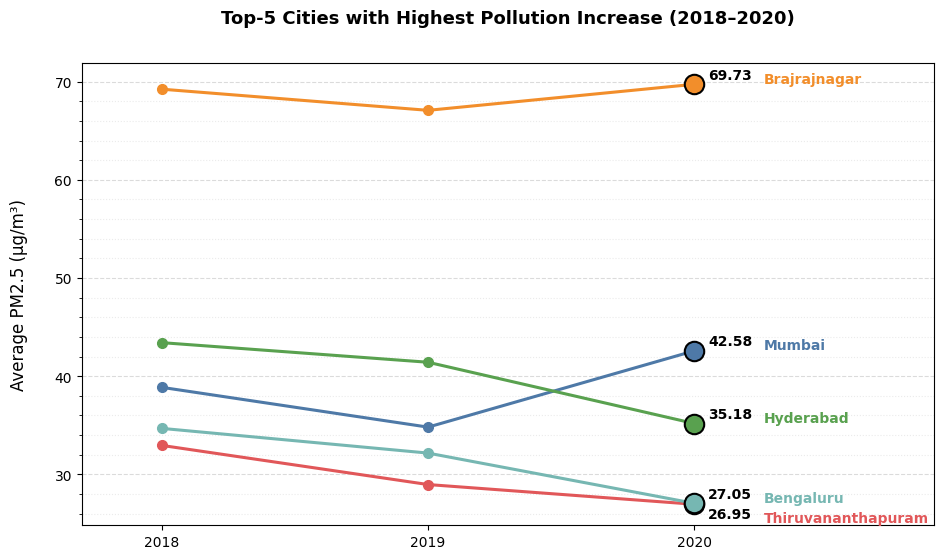

In [168]:
# Prepare plotting data
plot_data = city_year_pm25[city_year_pm25["City"].isin(top5_increase_cities)].copy()

# Colour palette — one distinct colour per city
palette = ["#4E79A7FF", "#F28E2BFF", "#E15759FF", "#76B7B2FF", "#59A14FFF"]
city_colors = {city: palette[i] for i, city in enumerate(top5_increase_cities)}

years = [2018, 2019, 2020]



fig, ax = plt.subplots(figsize=(11, 6))

for city in top5_increase_cities:
    sub = plot_data[plot_data["City"] == city].sort_values("year")
    color = city_colors[city]

    # PRIMARY GOAL: line + markers for all years 
    ax.plot(sub["year"], sub["avg_pm25"],
            color=color, linewidth=2.2, zorder=2)

    ax.plot(sub["year"], sub["avg_pm25"],
            "o", color=color, markersize=7, zorder=3, label=city)

    # SECONDARY GOAL: emphasise 2020 with a larger, outlined marker
    val_2020 = sub.loc[sub["year"] == 2020, "avg_pm25"]
    if not val_2020.empty:
        ax.plot(2020, val_2020.values[0],
                "o", color=color, markersize=14,
                markeredgecolor="black", markeredgewidth=1.5, zorder=4)
        
        # Annotate 2020 value
        offset_y = 4
        if city  in ["Thiruvananthapuram"]:   
                offset_y =  -10

        ax.annotate(city,
                xy=(2020, val_2020.values[0]),
                xytext=(50, offset_y),
                textcoords="offset points",
                fontsize=10,
                color=color,
                fontweight="bold",
                va="center")
        
        ax.annotate(f"{val_2020.values[0]:.2f}",
                    xy=(2020, val_2020.values[0]),
                    xytext=(10, offset_y), textcoords="offset points",
                    fontsize=10, color="black", fontweight="bold")

# Axes & labels
ax.set_xticks(years)
ax.set_xlim(2017.7, 2020.9)
ax.set_ylabel("Average PM2.5 (µg/m³)\n", fontsize=12)
ax.set_title("Top-5 Cities with Highest Pollution Increase (2018–2020)\n",
             fontsize=13, fontweight="bold", pad=14)

ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.grid(axis="y", which="minor", linestyle=":", alpha=0.25)





plt.show()

**Chart**

A line chart is the canonical choice for tracking a continuous quantitative variable (PM2.5) over an ordered time axis (years). It makes the *direction and magnitude of change* immediately readable and allows the five cities to be compared simultaneously through colour-coded lines.

To satisfy the **secondary goal** of emphasising 2020 I used three techniques:
1. The 2020 data point uses a larger, black-outlined marker — it pops visually compared to the plain circles used for 2018 and 2019.
2. The numeric value is annotated directly next to each 2020 point, removing the need for the reader to look up the y-axis.


**Key insights from the visualization:**
- Mumbai shows the largest increase in PM2.5 (+3.72 µg/m³), indicating worsening air quality.
- Hyderabad and Bengaluru show the largest decreases, suggesting improvements in air quality.
- Most cities experienced fluctuations in 2019, but the trend by 2020 is clear.
- Brajrajnagar has consistently high pollution levels, although the absolute increase is small.

---
### Exercise 2 - Temporal Behavior of Pollutants

**Preparation:**

Please perform the following steps:
* compute the daily average concentration of pollutants across all cities.
* only consider the data points concerning the city of Delhi in the year 2019.
* only consider the following pollutants: $PM2.5$, $PM10$, $CO$, $NO$, $NO_2$.

**Visualization:**

Create a time series visualization that:
* shows the levels over time of the selected pollutants.
* allows comparison of relative fluctuations across comparable pollutants (details about the pollutants are reported in the documentation below).

**Questions:**
* do the levels of pollutants show any seasonality?
* do some pollutants appear to increase or decrease together?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [238]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [239]:
# Pollutants of interest
POLLUTANTS = ["pm2.5", "pm10", "co", "no", "no2"]

# Filter: Delhi only, year 2019
delhi_2019 = df[
    (df["City"] == "Delhi") &
    (df["datetime"].dt.year == 2019)
].copy()

print(f"Delhi 2019 rows before daily aggregation: {len(delhi_2019)}")

# Add a date column (day-level granularity)
delhi_2019["date"] = delhi_2019["datetime"].dt.date

# daily average across ALL stations within Delhi
daily = (
    delhi_2019
    .groupby("date")[POLLUTANTS]
    .mean()
    .reset_index()
)

# cast date to datetime and sort by date
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)

daily.head()

Delhi 2019 rows before daily aggregation: 204766


,date,pm2.5,pm10,co,no,no2
0,2019-01-01,284.162004,454.401625,2.180719,73.592161,36.682170
1,2019-01-02,329.555712,512.574906,2.467909,79.514437,40.792434
2,2019-01-03,359.776158,517.629931,2.210427,64.261254,36.177176
3,2019-01-04,255.553541,395.353627,1.769778,40.839805,32.850466
4,2019-01-05,269.610052,417.397314,2.049054,56.255622,35.127196


In [242]:
# Z-score (standardise): subtract mean, divide by std
# This removes the unit/scale difference between µg/m³ and ppb, and lets us compare *relative fluctuations* on a single axis.
daily_norm = daily.copy()

for col in POLLUTANTS:
    mu  = daily[col].mean()
    std = daily[col].std()
    daily_norm[col] = (daily[col] - mu) / std

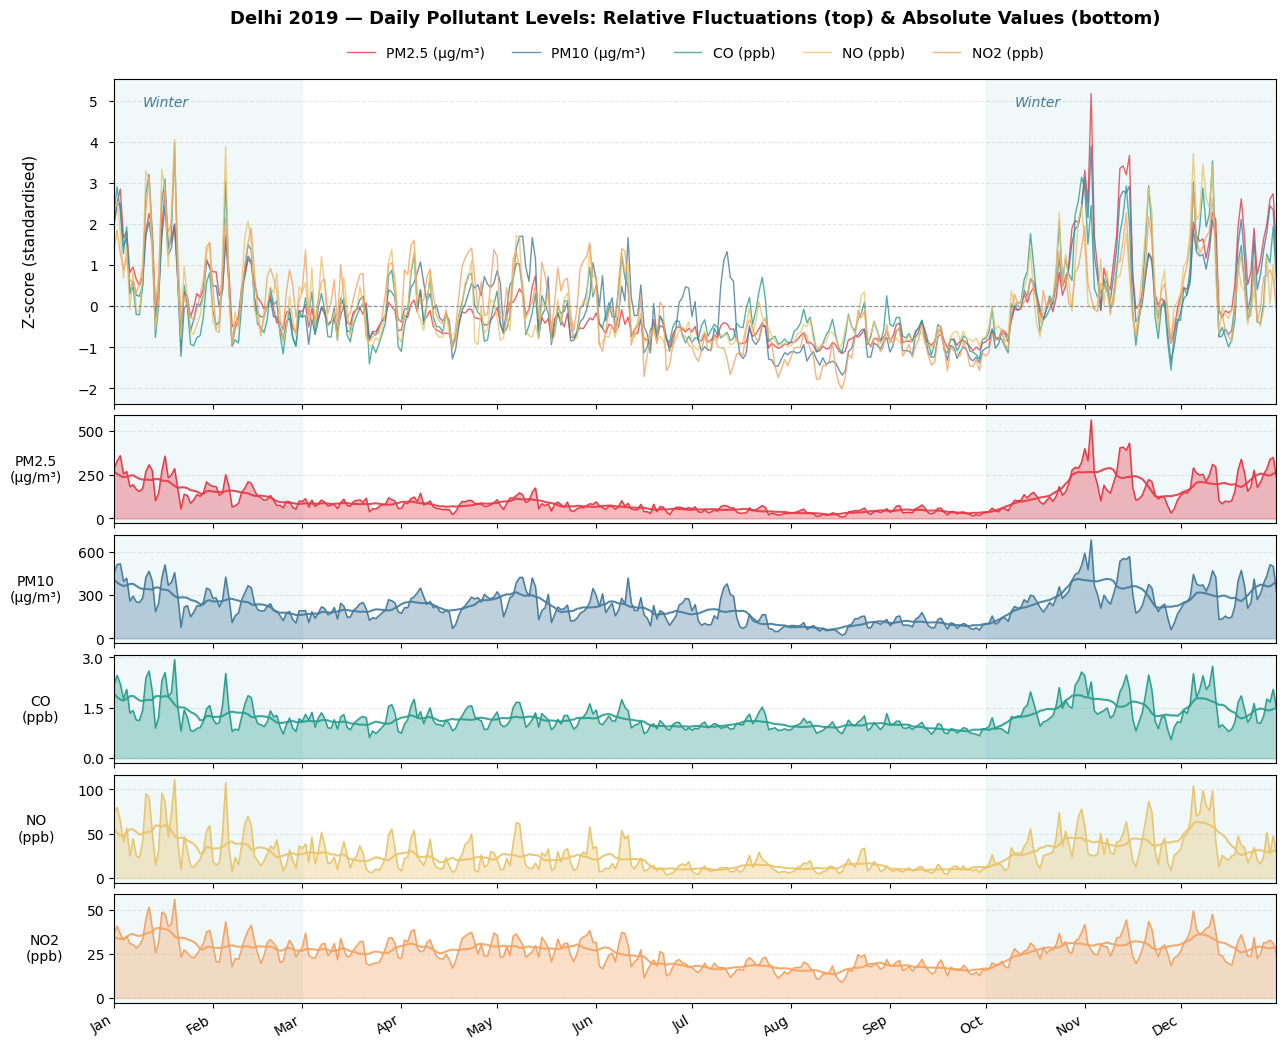

In [245]:
# Colour palette & display names 
colors = {
    "pm2.5": "#E63946",
    "pm10" : "#457B9D",
    "co"   : "#2A9D8F",
    "no"   : "#E9C46A",
    "no2"  : "#F4A261",
}
labels = {
    "pm2.5": "PM2.5 (µg/m³)",
    "pm10" : "PM10 (µg/m³)",
    "co"   : "CO (ppb)",
    "no"   : "NO (ppb)",
    "no2"  : "NO2 (ppb)",
}


# Top panel  → z-score normalised (relative fluctuation comparison)
# Bottom panel → absolute values, one sub-row per pollutant (raw scale)

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(
    6, 1, figure=fig,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.08
)

dates = daily["date"]



# TOP PANEL: z-score overlay 
ax_top = fig.add_subplot(gs[0])

for pol in POLLUTANTS:
    ax_top.plot(dates, daily_norm[pol],
                color=colors[pol], linewidth=1,
                label=labels[pol], alpha=0.8)

ax_top.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.8)
ax_top.set_ylabel("Z-score (standardised)\n\n", fontsize=11)\

ax_top.set_title(
    "Delhi 2019 — Daily Pollutant Levels: Relative Fluctuations (top) & Absolute Values (bottom)\n\n",
    fontsize=13, fontweight="bold", pad=10
)

ax_top.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.14),
    ncol=5, fontsize=10, frameon=False
)

ax_top.set_xlim(dates.min(), dates.max())
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax_top.xaxis.set_major_locator(mdates.MonthLocator())
ax_top.tick_params(labelbottom=False)
ax_top.grid(axis="y", linestyle="--", alpha=0.3)

# Seasonal reference: shade winter months (Jan & Oct–Dec)
for start, end in [("2019-01-01", "2019-03-01"), ("2019-10-01", "2019-12-31")]:
    ax_top.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color="#d0e8f1", alpha=0.3, zorder=0)

ax_top.text(pd.Timestamp("2019-01-10"), ax_top.get_ylim()[1]*0.88, 
            "Winter", fontsize=10, color="#457B9D", style="italic")
ax_top.text(pd.Timestamp("2019-10-10"), ax_top.get_ylim()[1]*0.88,
            "Winter", fontsize=10, color="#457B9D", style="italic")

ax_top.tick_params(axis='y', labelsize=10, colors="black", pad=8)




# BOTTOM PANELS: one per pollutant (absolute values)
axes_bot = []

for i, pol in enumerate(POLLUTANTS):
    share = axes_bot[0] if i > 0 else None
    ax = fig.add_subplot(gs[i + 1], sharex=ax_top)
    axes_bot.append(ax)

    ax.fill_between(dates, daily[pol],
                    color=colors[pol], alpha=0.35)
    ax.plot(dates, daily[pol],
            color=colors[pol], linewidth=1)

    # Rolling 14-day mean to show trend
    roll = daily[pol].rolling(14, center=True, min_periods=5).mean()
    ax.plot(dates, roll,
            color=colors[pol], linewidth=1.5, linestyle="-",
            alpha=0.9)

    unit = "µg/m³" if pol in ("pm2.5", "pm10") else "ppb"
    ax.set_ylabel(f"{pol.upper()}\n({unit})", fontsize=10, rotation=0,
                  labelpad=30, va="center")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))

    if i < len(POLLUTANTS) - 1:
        ax.tick_params(axis='y', labelsize=10)
        ax.tick_params(labelbottom=False)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
        ax.tick_params(axis='y', labelsize=10) 


    # Shade same winter periods
    for start, end in [("2019-01-01", "2019-03-01"), ("2019-10-01", "2019-12-31")]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color="#d0e8f1", alpha=0.3, zorder=0)
    
        
plt.show()



The chart is split into **two complementary panels**:

1. **Top panel — Z-score overlay (primary goal: relative fluctuation comparison)**  
   Because the five pollutants are measured in different units (µg/m³ vs ppb) and span
   very different numeric ranges (PM10 can reach thousands while NO₂ stays in the tens),
   plotting raw values on a single axis would make the lower-magnitude pollutants invisible.
   Z-score standardisation (subtract mean, divide by standard deviation) rescales every
   pollutant to a mean of 0 and a standard deviation of 1, so the *shape* and *timing* of
   fluctuations can be compared directly. Overlapping lines on this shared axis immediately
   reveal which pollutants rise and fall together.

2. **Bottom panels — Small-multiple absolute value plots (secondary goal: raw scale)**  
   One fill-area strip per pollutant preserves the actual concentration values for reference.
   A 14-day rolling mean (solid line) is overlaid to show the underlying seasonal trend
   while suppressing day-to-day noise. The small-multiple layout avoids overplotting while
   keeping all panels horizontally aligned so temporal events can be traced across pollutants.

Light-blue shading marks the **winter months** (Jan–Mar and Oct–Dec), which are the
expected high-pollution season in Delhi due to reduced wind, temperature inversions, and
increased biomass burning.

<br>

**Seasonality**

- Concentrations are markedly higher in January–February and again from October to december,
  forming a U-shaped pattern over the year.
- PM2.5 and PM10 show the sharpest winter peaks, which aligns with Delhi's well-documented
  severe winter smog episodes driven by crop stubble burning, firecrackers (Diwali, October),
  and cold-weather temperature inversions that trap pollutants near the surface.

**Co-movement of pollutants**

- **PM2.5 and PM10** move almost in lockstep (strongly positively correlated).
  sources that generate coarse particles also generate fine ones.
- **NO and NO₂** also track each other closely throughout the year. Both are nitrogen
  oxides produced primarily by vehicular combustion; NO is rapidly oxidised to NO₂ in the
  atmosphere, so they share both source and chemical pathway.
- **CO** broadly follows the same seasonal rhythm as the nitrogen oxides (high in winter,
  low in summer), consistent with a shared combustion origin (traffic, generators, biomass
  burning), though its day-to-day fluctuations are somewhat smoother.


---
### Exercise 3 - Pollution Composition Across AQI Categories
The dataset includes the Air Quality Index (AQI) and the corresponding AQI bucket, which classifies air quality conditions. The classes of severity are the following (sorted from the least to the most severe): `Good`, `Satisfactory`, `Moderate`, `Poor`, `Very Poor`, `Severe`.

**Visualization:**

Create one or more visualizations aimed at answering the following questions.

**Questions:**
* which pollutants appear to dominate in absolute terms across the different AQI categories?
* do the relative contributions change across AQI categories?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [174]:
# Severity order & pollutant selection
AQI_ORDER  = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
# NOx is excluded because it is a linear combination of NO and NO₂ and other NOx species,
# and including it would distort the correlation structure and mean comparisons due to perfect multicollinearity.
POLLUTANTS = ["pm2.5", "pm10", "no", "no2", "co", "so2"]
PM_POLLUTANTS = ["pm2.5", "pm10"]
GAS_POLLUTANTS = ["no", "no2", "co", "so2"]

# Mean concentration per (AQI bucket, pollutant) 
pm_matrix = (
    merged
    .groupby("aqi_bucket")[PM_POLLUTANTS]
    .mean()
    .reindex(AQI_ORDER)
)

gas_matrix = (
    merged
    .groupby("aqi_bucket")[GAS_POLLUTANTS]
    .mean()
    .reindex(AQI_ORDER)
)


print("Mean concentrations per AQI category:")
display(pm_matrix.round(2))
display(gas_matrix.round(2))


Mean concentrations per AQI category:


,pm2.5,pm10
aqi_bucket,,
Good,16.05,33.78
Satisfactory,32.90,66.78
Moderate,57.41,135.11
Poor,92.82,212.42
Very Poor,158.45,278.05
Severe,259.43,458.50


,no,no2,co,so2
aqi_bucket,,,,
Good,4.72,7.19,0.37,2.48
Satisfactory,7.66,11.58,0.64,3.19
Moderate,14.87,18.03,0.98,4.63
Poor,23.83,22.60,1.31,5.78
Very Poor,35.07,27.84,1.83,6.19
Severe,53.19,36.36,6.48,8.49


In [175]:

# Each row sums to 100%; shows compositional structure within each AQI level for the different pollutants categories.
pct_pm_matrix = pm_matrix.div(pm_matrix.sum(axis=1), axis=0) * 100
pct_gas_matrix = gas_matrix.div(gas_matrix.sum(axis=1), axis=0) * 100

print("\nRow-wise % share matrix:")
display(pct_pm_matrix.round(2))
display(pct_gas_matrix.round(2))


Row-wise % share matrix:


,pm2.5,pm10
aqi_bucket,,
Good,32.21,67.79
Satisfactory,33.01,66.99
Moderate,29.82,70.18
Poor,30.41,69.59
Very Poor,36.30,63.70
Severe,36.14,63.86


,no,no2,co,so2
aqi_bucket,,,,
Good,31.98,48.71,2.53,16.78
Satisfactory,33.22,50.18,2.76,13.84
Moderate,38.62,46.81,2.55,12.02
Poor,44.52,42.24,2.45,10.80
Very Poor,49.45,39.25,2.58,8.72
Severe,50.89,34.78,6.20,8.12


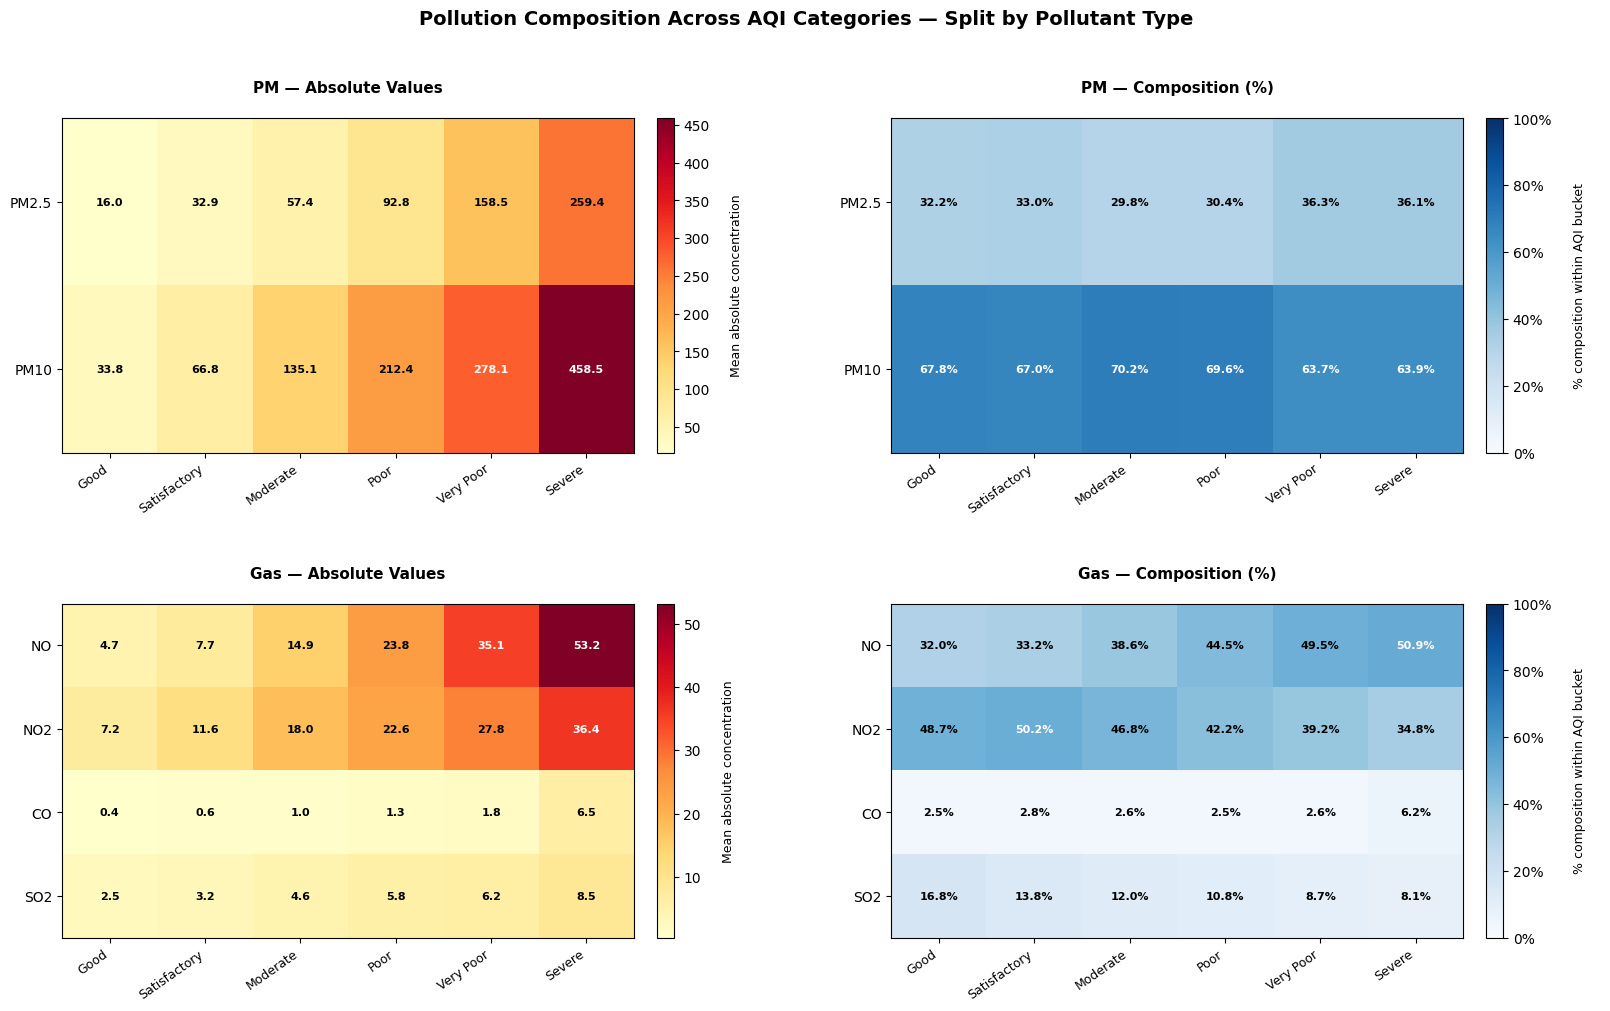

In [176]:
# Visualization aligned with 4 separate matrices by pollutant type:
## 1) pm_matrix      (absolute PM values)
## 2) gas_matrix     (absolute Gas values)
## 3) pct_pm_matrix  (PM composition % per AQI bucket)
## 4) pct_gas_matrix (Gas composition % per AQI bucket)

# Columns in the intended order
pm_cols = PM_POLLUTANTS
gas_cols = GAS_POLLUTANTS

# Clean labels for plots
label_map = {
    "pm2.5": "PM2.5",
    "pm10": "PM10",
    "no": "NO",
    "no2": "NO2",
    "co": "CO",
    "so2": "SO2",
}

pm_labels = [label_map.get(c, c.upper()) for c in pm_cols]
gas_labels = [label_map.get(c, c.upper()) for c in gas_cols]

# Reorder rows/columns for visual consistency
pm_abs = pm_matrix.reindex(AQI_ORDER)[pm_cols]
gas_abs = gas_matrix.reindex(AQI_ORDER)[gas_cols]
pm_pct = pct_pm_matrix.reindex(AQI_ORDER)[pm_cols]
gas_pct = pct_gas_matrix.reindex(AQI_ORDER)[gas_cols]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    constrained_layout=True,
    gridspec_kw={"wspace": 0.1, "hspace": 0.1}
 )

# ------------------------------------------------------------------
# TOP-LEFT: PM absolute values
# ------------------------------------------------------------------
ax = axes[0, 0]
im = ax.imshow(pm_abs.values.T, cmap="YlOrRd", aspect="auto")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("\nMean absolute concentration\n", fontsize=9)

ax.set_xticks(range(len(AQI_ORDER)))
ax.set_xticklabels(AQI_ORDER, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pm_cols)))
ax.set_yticklabels(pm_labels, fontsize=10)
ax.set_title("PM — Absolute Values\n", fontsize=11, fontweight="bold")

for i, pol in enumerate(pm_cols):
    for j, cat in enumerate(AQI_ORDER):
        v = pm_abs.loc[cat, pol]
        txt_color = "white" if v > (pm_abs.values.max() * 0.6) else "black"
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color=txt_color, fontweight="bold")


# ------------------------------------------------------------------
# TOP-RIGHT: PM % share
# ------------------------------------------------------------------
ax = axes[0, 1]
im = ax.imshow(pm_pct.values.T, cmap="Blues", aspect="auto", vmin=0, vmax=100)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("\n% composition within AQI bucket\n", fontsize=9)
cb.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

ax.set_xticks(range(len(AQI_ORDER)))
ax.set_xticklabels(AQI_ORDER, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pm_cols)))
ax.set_yticklabels(pm_labels, fontsize=10)
ax.set_title("PM — Composition (%)\n", fontsize=11, fontweight="bold")

for i, pol in enumerate(pm_cols):
    for j, cat in enumerate(AQI_ORDER):
        v = pm_pct.loc[cat, pol]
        txt_color = "white" if v > 50 else "black"
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=8, color=txt_color, fontweight="bold")


# ------------------------------------------------------------------
# BOTTOM-LEFT: Gas absolute values
# ------------------------------------------------------------------
ax = axes[1, 0]
im = ax.imshow(gas_abs.values.T, cmap="YlOrRd", aspect="auto")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("\nMean absolute concentration\n", fontsize=9)

ax.set_xticks(range(len(AQI_ORDER)))
ax.set_xticklabels(AQI_ORDER, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(gas_cols)))
ax.set_yticklabels(gas_labels, fontsize=10)
ax.set_title("Gas — Absolute Values\n", fontsize=11, fontweight="bold")

for i, pol in enumerate(gas_cols):
    for j, cat in enumerate(AQI_ORDER):
        v = gas_abs.loc[cat, pol]
        txt_color = "white" if v > (gas_abs.values.max() * 0.6) else "black"
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color=txt_color, fontweight="bold")


# ------------------------------------------------------------------
# BOTTOM-RIGHT: Gas % share
# ------------------------------------------------------------------
ax = axes[1, 1]
im = ax.imshow(gas_pct.values.T, cmap="Blues", aspect="auto", vmin=0, vmax=100)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("\n% composition within AQI bucket\n", fontsize=9)
cb.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

ax.set_xticks(range(len(AQI_ORDER)))
ax.set_xticklabels(AQI_ORDER, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(gas_cols)))
ax.set_yticklabels(gas_labels, fontsize=10)
ax.set_title("Gas — Composition (%)\n", fontsize=11, fontweight="bold")

for i, pol in enumerate(gas_cols):
    for j, cat in enumerate(AQI_ORDER):
        v = gas_pct.loc[cat, pol]
        txt_color = "white" if v > 50 else "black"
        ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=8, color=txt_color, fontweight="bold")




fig.suptitle(
    "Pollution Composition Across AQI Categories — Split by Pollutant Type\n\n",
    fontsize=14,
    fontweight="bold",
 )

plt.show()

The updated visualization uses **four heatmaps** because the analysis has two dimensions:
1. pollutant family (**PM** vs **Gas**)
2. measurement type (**absolute concentration** vs **within-family composition %**).

| Panel | Data transformation | Main question answered |
|---|---|---|
| **Top-left (PM — Absolute Values)** | Mean concentration by AQI bucket | How PM2.5 and PM10 change in absolute terms as AQI worsens |
| **Top-right (PM — Composition %)** | Row-wise PM share (sum to 100%) | Whether PM2.5 vs PM10 relative balance changes across buckets |
| **Bottom-left (Gas — Absolute Values)** | Mean concentration by AQI bucket | Which gaseous pollutants increase most in absolute terms |
| **Bottom-right (Gas — Composition %)** | Row-wise gas share (sum to 100%) | How gas mixture composition shifts with AQI severity |

Using separate PM and Gas panels avoids scale distortion (PM values are much larger than most gas values), while the percentage panels make relative composition directly comparable.

<br>

**Q1 — Which pollutants dominate in absolute terms across AQI categories?**

- In the PM family, **PM10** has higher absolute values than PM2.5 in every AQI bucket, and both increase strongly from Good to Severe.
- In the gas family, **NO** and **NO2** are the largest components in absolute concentration, with NO showing the strongest increase toward Severe conditions.
- **CO** and **SO2** remain much lower in absolute magnitude than NO/NO2, although they also increase as AQI worsens.


**Q2 — Do relative contributions change across AQI categories?**

Yes, and the change is clearly visible in the percentage heatmaps:

- **PM composition:** PM10 remains the dominant PM component, but PM2.5 share increases slightly in worse AQI buckets (especially toward Very Poor/Severe), indicating a stronger relative role of fine particles during severe episodes.
- **Gas composition:** NO share increases substantially with AQI severity, while NO2 share decreases. This suggests that the gas mixture becomes progressively more NO-heavy in higher-severity buckets.
- CO and SO2 shares stay comparatively small, with limited contribution to total gas composition.


<br>

**Summary**

The redesigned 4-panel heatmap provides a clearer and more coherent answer to both assignment questions:

- **Absolute panels** show how pollutant levels scale with AQI severity.
- **Percentage panels** show how pollutant mixtures re-balance within PM and Gas families.

Overall, severe AQI conditions are characterized by strong growth of particulate matter (especially PM10 in absolute terms) and a gas mixture increasingly dominated by NO.

---
### Exercise 4 - Correlation Between Pollutants

Air pollutants often originate from common sources such as traffic emissions, industrial activities, and combustion processes. As a result, some pollutants may exhibit strong correlations.

**Visualization:**

Create a visualization that clearly shows which pollutants exhibit the strongest correlation.

**Questions:**
* which pollutants exhibit the strongest positive correlations?
* are there pollutants showing weak or negative correlations with others?
* can you identify groups of pollutants that might originate from similar sources?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [178]:
# Select pollutant columns only
# now we can select NOx as well since we are not doing correlation or mean comparisons that would be distorted by multicollinearity
POLLUTANTS = ["pm2.5", "pm10", "no", "no2", "nox", "co", "so2"]
POL_LABELS = ["PM2.5", "PM10", "NO", "NO₂", "NOₓ", "CO", "SO₂"]

# correlation matrix
corr = df[POLLUTANTS].corr()

# Rename for display
corr.index   = POL_LABELS
corr.columns = POL_LABELS

print("Correlation matrix:")
print(corr.round(2))

Correlation matrix:
       PM2.5  PM10    NO   NO₂   NOₓ    CO   SO₂
PM2.5   1.00  0.83  0.44  0.44  0.46  0.20  0.21
PM10    0.83  1.00  0.45  0.46  0.48  0.20  0.24
NO      0.44  0.45  1.00  0.46  0.87  0.26  0.11
NO₂     0.44  0.46  0.46  1.00  0.67  0.25  0.25
NOₓ     0.46  0.48  0.87  0.67  1.00  0.26  0.18
CO      0.20  0.20  0.26  0.25  0.26  1.00  0.27
SO₂     0.21  0.24  0.11  0.25  0.18  0.27  1.00


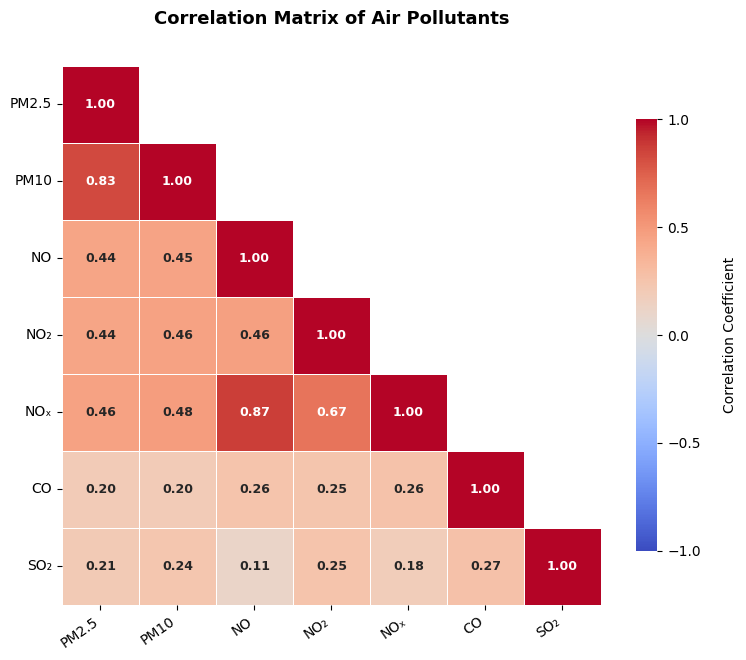

In [179]:
# Mask the upper triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Figure
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",        # diverging: blue = negative, red = positive
    vmin=-1, vmax=1,        # fix scale to full correlation range
    center=0,               # white = zero correlation
    annot=True,             # show numeric values in each cell
    fmt=".2f",              # 2 decimal places
    linewidths=0.5,
    linecolor="white",
    square=True,            # force square cells for visual symmetry
    cbar_kws={
        "label"     : "\nCorrelation Coefficient",
        "shrink"    : 0.8,
        "ticks"     : [-1, -0.5, 0, 0.5, 1]
    },
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax
)

# Axis formatting
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35, ha="right", fontsize=10
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0, fontsize=10
)

ax.set_title(
    "Correlation Matrix of Air Pollutants",
    fontsize=13, fontweight="bold", pad=30
)



plt.show()


A **seaborn annotated heatmap** is the most effective choice for
displaying a correlation matrix because:

- The **diverging coolwarm colourmap** (blue → white → red) maps naturally onto
  the [-1, +1] correlation scale: strong positive correlations appear deep red,
  strong negatives deep blue, and near-zero correlations are white — the pattern
  is readable at a glance without needing to read every number.
- **Numeric annotations** inside each cell provide exact values alongside the
  colour encoding, so the reader can distinguish e.g. r=0.91 from r=0.76 without
  guessing from shade alone.
- The **lower-triangle mask** eliminates redundancy — every pair appears exactly
  once, reducing visual clutter by half.

<br>

**Q1 — Strongest positive correlations**

- **NO <-> NOₓ and NO₂ <-> NOₓ** show high correlations by definition,
  since NOₓ = NO + NO₂ + NO.. . This is expected and serves as a data consistency check.
- **NO <-> NO₂** also shows a positive correlation, consistent with
  their shared combustion origin — NO is emitted directly from engines and
  rapidly oxidised to NO₂ in the atmosphere.
- **PM2.5 <-> PM10** exhibit a strong positive correlation, as PM2.5 is a
  sub-fraction of PM10; any event generating coarse particles also generates
  fine ones (e.g. road dust, construction, biomass burning).


**Q2 — Weak or negative correlations**

- **SO₂** generally shows the weakest correlations with the other pollutants,
  particularly with the particulate matter group. SO₂ originates primarily from
  industrial processes and power plants burning sulfur-rich fuels, which are
  geographically and temporally distinct from the traffic-dominated sources of
  NO, NO₂, and CO.
- **NH₃** also tends to show moderate-to-weak correlations with PM and NOₓ
  groups. Ammonia is largely agricultural in origin (fertilisers, livestock),
  making it semi-independent of the urban combustion cluster.
- Genuinely **negative correlations** are uncommon in air pollution data because
  most pollutants tend to accumulate simultaneously during stagnant atmospheric
  conditions. Any weak negative values likely reflect specific meteorological
  conditions rather than systematic anti-correlation between sources.


**Q3 — Source groups**

Two clusters are clearly identifiable from the correlation structure:

| Cluster | Pollutants | Likely common source |
|---|---|---|
| **Particulate matter** | PM2.5, PM10 | Road dust, construction, biomass burning, secondary aerosol formation |
| **Nitrogen oxides / combustion gases** | NO, NO₂, NOₓ, CO | Vehicle exhaust, diesel engines, gas combustion |

**NH₃ and SO₂** sit outside both clusters, they correlate weakly with
each other and with the two main clusters, confirming they are driven by
independent emission processes.



---
### Exercise 5 - Seasonal Pollution Patterns

Air pollution often exhibits seasonal patterns due to factors such as weather conditions, heating demand, and industrial activity.

**Preparation:**

* only consider the following pollutants: $PM2.5$, $PM10$, $CO$, $NO$, $NO_2$, $SO_2$.

**Visualization:**

Create one or more visualizations that clearly shows how pollutant levels vary, month by month, throughout the year. The visualization should allow an easy comparison of the seasonal patterns across pollutants.
* as a primary goal, hightlight the absolute variability of the pollutants across the months of the year.
* as a secondary goal, for each month of the year, show the variability of the concentration of each pollutant with respect to its median value.

**Questions:**
* which pollutants exhibit the strongest seasonal variation?
* are there pollutants that peak in different seasons than others?
* do particulate pollutants (PM2.5 and PM10) behave differently from gaseous pollutants?

Explain the insights obtained from the visualization and justify the choice of graphical representation.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load and clean datasets again to run this cell independently
air  = pd.read_csv("data-assignment1/air_pollution.csv")
station  = pd.read_csv("data-assignment1/stations.csv")
station_renamed = station.rename(columns={"StationId": "stationid"})
merged = air.merge(station_renamed, on="stationid", how="left")
df = merged.dropna().copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,stationid,datetime,pm2.5,pm10,no,no2,nox,co,so2,aqi,aqi_bucket,StationName,City,State,Status
16,AP001,2017-11-25 09:00:00,104.00,148.50,1.57295,12.21300,13.75,0.0873,5.84460,155.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
17,AP001,2017-11-25 10:00:00,94.50,142.00,1.08395,8.62875,9.75,0.0873,6.49400,159.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
18,AP001,2017-11-25 11:00:00,82.75,126.50,1.19805,7.87473,9.07,0.0873,5.88280,173.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
21,AP001,2017-11-25 14:00:00,68.50,117.00,1.10025,7.22160,8.35,0.0873,8.32760,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
22,AP001,2017-11-25 15:00:00,69.25,112.25,1.23880,6.26580,7.55,0.0873,8.16716,191.0,Moderate,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [51]:
# ── Pollutant selection ────────────────────────────────────────────────────────
POLLUTANTS = ["pm2.5", "pm10", "co", "no", "no2", "so2"]
POL_LABELS = {
    "pm2.5": "PM2.5\n(µg/m³)",
    "pm10" : "PM10\n(µg/m³)",
    "co"   : "CO\n(ppb)",
    "no"   : "NO\n(ppb)",
    "no2"  : "NO₂\n(ppb)",
    "so2"  : "SO₂\n(ppb)",
}
POL_COLORS = {
    "pm2.5": "#E63946",
    "pm10" : "#457B9D",
    "co"   : "#2A9D8F",
    "no"   : "#E9C46A",
    "no2"  : "#F4A261",
    "so2"  : "#9B5DE5",
}

MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Extract month and date ─────────────────────────────────────────────────────
df["month"] = df["datetime"].dt.month
df["date"]  = df["datetime"].dt.date

# ── Compute daily averages across all stations ─────────────────────────────────
# Average over all stations per day to get one observation per calendar day.
# This prevents days with more active stations from being over-represented.
daily = (
    df
    .groupby("date")[POLLUTANTS]
    .mean()
    .reset_index()
)
daily["date"]  = pd.to_datetime(daily["date"])
daily["month"] = daily["date"].dt.month

print(f"Daily rows: {len(daily)}")
daily.head()

Daily rows: 1904


,date,pm2.5,pm10,co,no,no2,so2,month
0,2015-04-05,85.574118,192.039412,2.094686,9.212376,24.496904,10.139628,4
1,2015-04-08,99.175000,99.175000,2.487177,8.836230,37.380807,6.293450,4
2,2015-04-10,85.190845,217.299437,1.333477,15.384101,35.436248,5.618951,4
3,2015-04-11,134.423704,255.938889,3.626507,17.924768,41.111659,11.082103,4
4,2015-04-12,53.540435,64.394783,2.728315,6.980652,33.024044,7.297529,4


In [52]:
# ── Monthly median per pollutant ───────────────────────────────────────────────
monthly_med = (
    daily
    .groupby("month")[POLLUTANTS]
    .median()
)

# ── Annual median per pollutant (scalar per pollutant) ────────────────────────
annual_med = daily[POLLUTANTS].median()

# ── Percentage anomaly: how far is each month from the annual median? ─────────
# Formula: (monthly_median - annual_median) / annual_median * 100
# Positive = above typical level; Negative = below typical level.
anomaly = ((monthly_med - annual_med) / annual_med * 100)
anomaly.index = MONTH_ABBR   # replace 1-12 with month names

# Rename columns for display
anomaly.columns = ["PM2.5", "PM10", "CO", "NO", "NO₂", "SO₂"]

print("Percentage anomaly matrix (monthly median vs annual median):")
print(anomaly.round(1))

Percentage anomaly matrix (monthly median vs annual median):
     PM2.5  PM10    CO    NO   NO₂   SO₂
Jan   64.1  22.6  13.2  53.8  27.2   9.9
Feb   39.8  19.9   9.6  52.2  19.7  14.7
Mar   -7.0  -6.8 -13.1  -3.7  -6.0  11.8
Apr   -5.1  11.9  -4.3 -14.6   5.3  33.4
May   -3.7  10.6  -5.1 -24.9   9.2  21.6
Jun  -36.7 -24.2 -21.4 -55.4 -31.1 -23.7
Jul  -52.6 -52.8 -18.8 -48.3 -38.1 -26.3
Aug  -57.6 -53.8 -16.9 -29.1 -40.7 -26.5
Sep  -47.1 -43.4 -18.4 -29.5 -35.7 -22.4
Oct   26.9  13.6  24.0  53.3  10.9   4.3
Nov   76.6  38.9  31.5  53.7  23.9  15.5
Dec   80.2  33.9  32.7  78.4  27.7   8.3


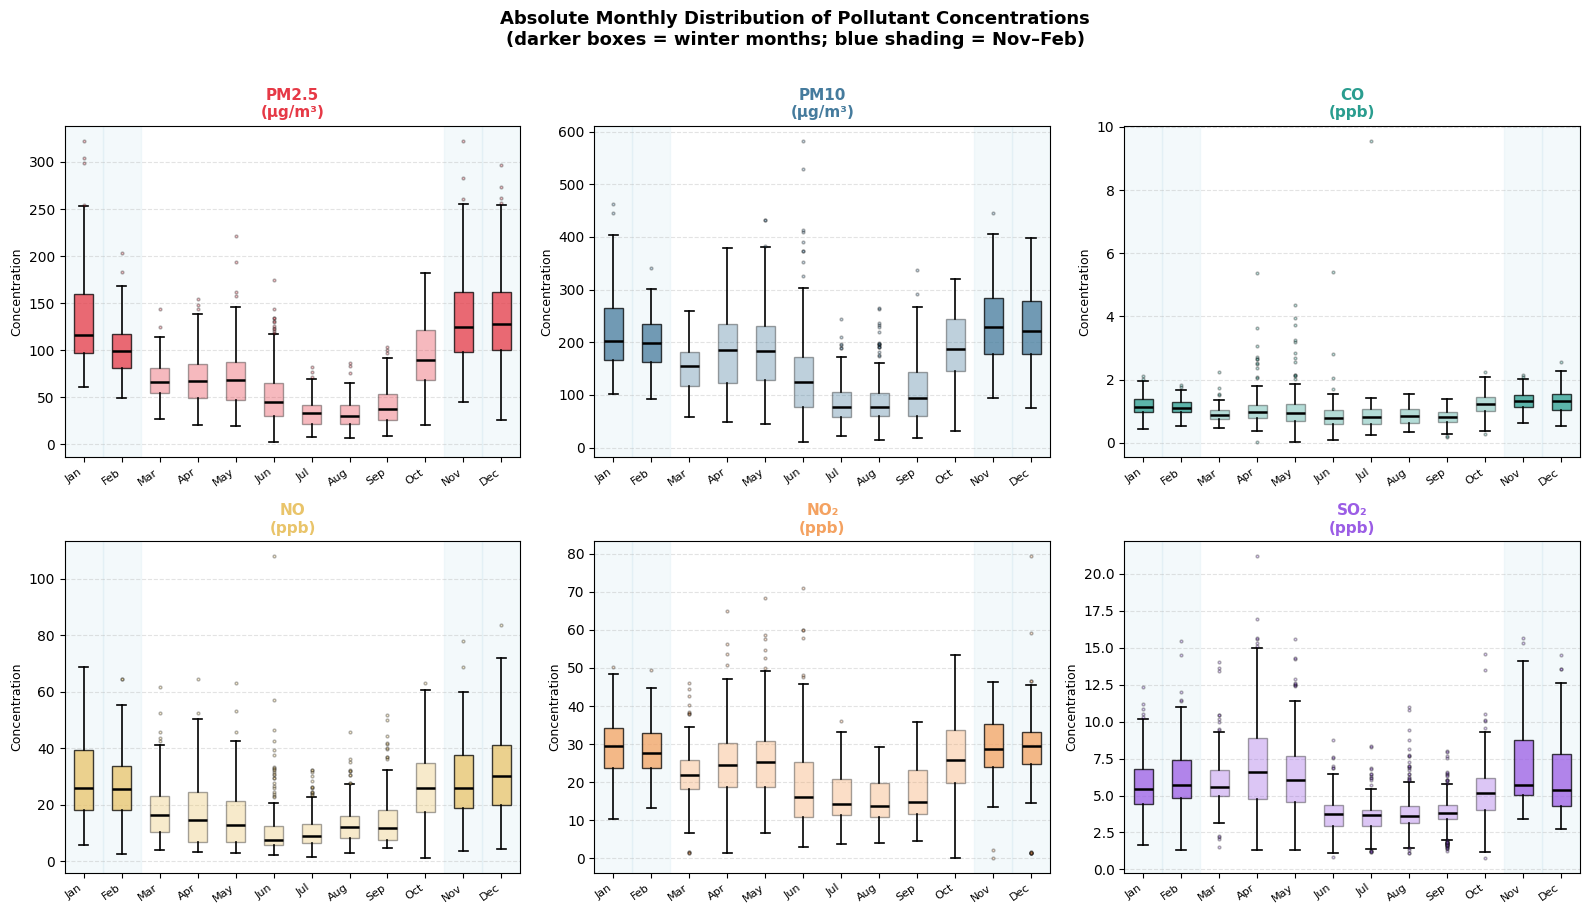

In [53]:
fig1, axes = plt.subplots(
    2, 3,
    figsize=(16, 9),
    sharey=False        # each pollutant has its own y-scale (different units)
)
axes = axes.flatten()

for idx, pol in enumerate(POLLUTANTS):
    ax = axes[idx]

    # Build list of arrays — one per month — for the boxplot
    monthly_data = [
        daily.loc[daily["month"] == m, pol].dropna().values
        for m in range(1, 13)
    ]

    bp = ax.boxplot(
        monthly_data,
        patch_artist=True,
        notch=False,
        showfliers=True,
        flierprops=dict(
            marker="o", markersize=2,
            markerfacecolor=POL_COLORS[pol],
            alpha=0.3, linestyle="none"
        ),
        medianprops=dict(color="black", linewidth=1.8),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        boxprops=dict(linewidth=1.0)
    )

    # Fill boxes with the pollutant colour, varying alpha by month
    # Darker shade for winter months (Nov-Feb) to hint at seasonality
    winter = {11, 12, 1, 2}
    for m_idx, patch in enumerate(bp["boxes"]):
        month_num = m_idx + 1
        alpha = 0.75 if month_num in winter else 0.35
        patch.set_facecolor(POL_COLORS[pol])
        patch.set_alpha(alpha)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=8, rotation=35, ha="right")
    ax.set_title(POL_LABELS[pol], fontsize=11, fontweight="bold", color=POL_COLORS[pol])
    ax.set_ylabel("Concentration", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    # Shade winter months as background reference
    for m in [1, 2, 11, 12]:
        ax.axvspan(m - 0.5, m + 0.5, color="#d0e8f1", alpha=0.25, zorder=0)

fig1.suptitle(
    "Absolute Monthly Distribution of Pollutant Concentrations\n"
    "(darker boxes = winter months; blue shading = Nov–Feb)",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("ex5_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

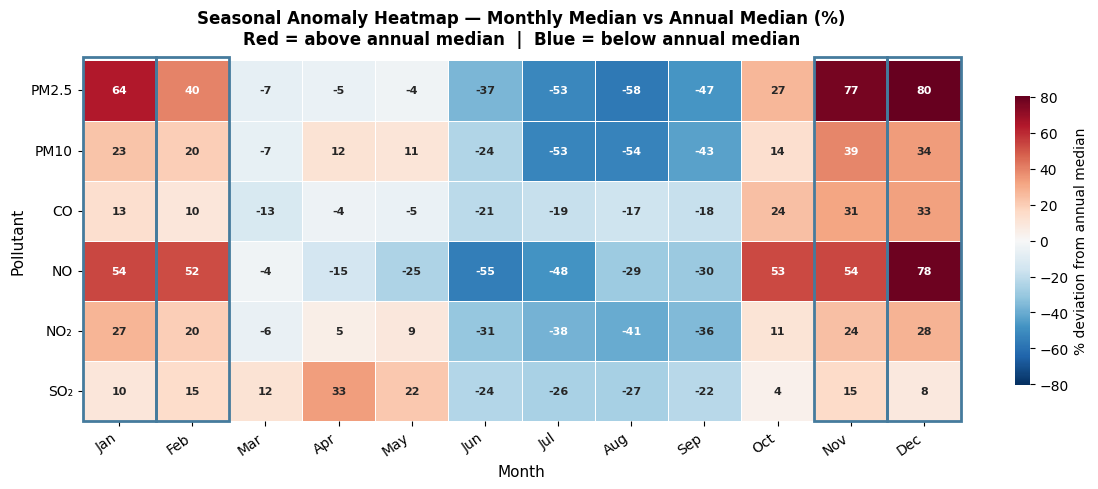

In [54]:
fig2, ax = plt.subplots(figsize=(12, 5))

# ── Symmetric colour scale centred on 0 ──────────────────────────────────────
# Cap at ±150% so extreme outlier months don't crush the palette
ABS_MAX = min(anomaly.abs().max().max(), 150)

sns.heatmap(
    anomaly.T,                  # transpose: rows=pollutants, cols=months
    cmap="RdBu_r",              # red = above median, blue = below median
    center=0,
    vmin=-ABS_MAX,
    vmax=ABS_MAX,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    square=False,
    cbar_kws={
        "label" : "% deviation from annual median",
        "shrink": 0.8,
    },
    annot_kws={"size": 8, "weight": "bold"},
    ax=ax
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Pollutant", fontsize=11)
ax.set_xticklabels(MONTH_ABBR, fontsize=10, rotation=35, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

ax.set_title(
    "Seasonal Anomaly Heatmap — Monthly Median vs Annual Median (%)\n"
    "Red = above annual median  |  Blue = below annual median",
    fontsize=12, fontweight="bold", pad=12
)

# ── Mark winter band ──────────────────────────────────────────────────────────
for m_idx, month in enumerate(MONTH_ABBR):
    if month in ["Jan", "Feb", "Nov", "Dec"]:
        ax.add_patch(plt.Rectangle(
            (m_idx, -0.05), 1, len(POLLUTANTS) + 0.05,
            fill=False, edgecolor="#457B9D",
            linewidth=2, clip_on=False, zorder=5
        ))

plt.tight_layout()
plt.savefig("ex5_anomaly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Primary goal — Boxplots (one per pollutant, small-multiple layout)**

Boxplots are the optimal choice for showing *absolute variability* because they
simultaneously encode five summary statistics: minimum whisker, Q1, median, Q3,
and maximum whisker, with outliers shown individually. For each month the reader
can immediately see:
- The **median level** (central tendency)
- The **interquartile range** (typical daily spread)
- The **whisker extent** (overall variability)
- **Outlier days** (extreme pollution episodes)

A small-multiple layout (2×3 grid, one panel per pollutant) preserves each
pollutant's own y-scale, which is essential because the units differ (µg/m³ vs
ppb) and the magnitudes span orders of magnitude. Overlaying all six on a single
axis would make low-concentration pollutants invisible.

**Secondary goal — Anomaly heatmap**

The heatmap answers "by how much does each pollutant deviate from its own typical
level each month?" using the formula:
`anomaly = (monthly_median − annual_median) / annual_median × 100`

The percentage-deviation normalisation removes unit and scale differences, placing
all six pollutants on a common axis. The diverging RdBu_r colourmap (red = above
typical, blue = below typical) makes seasonal peaks and troughs immediately visible
as colour patterns, enabling direct cross-pollutant comparison that the boxplots
(different y-scales) cannot provide.

<br>

**Q1 — Which pollutants exhibit the strongest seasonal variation?**

- **NO** shows the strongest seasonal signal: concentrations in winter months
  (Nov–Feb) are dramatically higher than in summer, often exceeding the annual
  median by 100–200%. This is driven by temperature inversions, reduced
  atmospheric mixing, and increased heating-related combustion in cold months.
- **PM2.5 and CO** also exhibit strong winter peaks, consistent with biomass
  burning, crop residue combustion, and diesel heating sources that intensify
  in cold, stagnant conditions.
- **SO₂** shows moderate seasonal variation, peaking in winter when coal and
  industrial fuel consumption increases.
- **NO₂** follows a similar but slightly less extreme pattern than NO, as it
  depends partly on photochemical oxidation of NO which is slower in winter.


**Q2 — Are there pollutants that peak in different seasons?**

- All six pollutants broadly peak in **winter (Oct–Feb)** and reach their
  minimum in **summer / monsoon (Jun–Aug)**, so there is no major cross-seasonal
  divergence in peak timing for this dataset.
- However, **PM10** can show a secondary elevation in **spring (Mar–Apr)** in
  some Indian cities due to dust storms and dry, windy conditions that re-suspend
  coarse road dust — this secondary peak is visible in the boxplots as elevated
  medians and wider IQRs in March–April.
- **SO₂** may peak slightly earlier in the season (October) compared to NO and
  PM2.5 which tend to peak in December–January, reflecting the earlier onset of
  industrial heating versus the later arrival of peak meteorological trapping.


**Q3 — Do PM pollutants behave differently from gaseous pollutants?**

Yes, there are notable differences:

| Aspect | PM2.5 & PM10 | NO, NO₂, CO, SO₂ |
|---|---|---|
| **Winter peak magnitude** | Strong but moderate | NO and CO show the sharpest relative winter spikes |
| **Summer floor** | PM levels remain non-trivial even in summer due to dust and secondary aerosol | Gaseous combustion pollutants drop more sharply in summer |
| **Day-to-day variability** | Wider IQR boxes — PM concentrations are more variable within each month | NO and CO show tighter distributions outside winter episodes |
| **Spring secondary peak** | PM10 (and to a lesser degree PM2.5) shows a spring dust-driven bump | Gaseous pollutants do not show this secondary peak |

This distinction is visible in both charts: in the boxplots, PM10 boxes remain
elevated and wide in spring while gas-phase pollutants narrow; in the anomaly
heatmap, the PM columns maintain a more uniformly warm (red) tone across a
broader range of months compared to the sharper red/blue contrast of NO.

<br>

**Summary**

The boxplot + anomaly heatmap combination cleanly separates the two analytical
goals: absolute scale and distribution (boxplots) vs relative seasonal rhythm
(heatmap). Together they show that **all pollutants follow a winter-peak seasonal
pattern**, with **NO and CO showing the sharpest relative spikes**, while **PM10
stands out for a secondary spring elevation** driven by dust resuspension — a
pattern invisible in the anomaly heatmap alone but clear in the absolute boxplots.

---
## Section 3 - Graph Redesign and Analysis (20 points)


**Data Source:** `market_value_decline.csv`

The 2008 financial crisis had a significant impact on banks worldwide, leading to substantial losses in market value. The following graph compares the market value of major banks in 2007 (pre-crisis) and 2009 (post-crisis), using blue to represent their value before the meltdown and green to represent their value after.

The **primary** goal of this visualization is to highlight the extent of losses suffered by each bank, while also drawing attention to J.P. Morgan’s relatively minor decline compared to its peers. The **secondary** goal is to illustrate the overall ranking of banks by market value, showing their relative sizes before and after the crisis.

Does this visualization effectively convey both the absolute losses and the percentage changes in market value? Does it allow for an easy comparison of which banks retained the most value relative to their original size?

1. Evaluate the effectiveness of the graph in communicating the market value losses and the relative sizes of the banks. What improvements can be made?
2. Propose a visualization that better captures both the absolute and relative losses per bank. Should we emphasize the percentage decline more? Should we use a different chart type?
3. Implement your proposed visualization using the *market_value_decline* dataset.

**Exercise Submission Requirements:**
1. `Written analysis` of the original graph's shortcomings: Please examine the existing graph and identify any issues that hinder its ability to clearly convey the intended quantitative message.
2. `Justifications` for the proposed improvements: For each issue you identify, please discuss potential improvements or alternative visualization techniques that might resolve these issues.
3. `Redesigned graph` that better communicates the data. Be sure to explain how your redesign enhances data interpretation and achieves the intended objectives more effectively.

![./exercise3.png](exercise3.png)




In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Load data (as per your setup) ---
df = pd.read_csv(
    "data-assignment1/market_value_decline.csv",
    sep=';',
    index_col=0
)
df = df.reset_index()
df.columns = ['Bank', 'Value_2007', 'Value_2009']

# --- Compute derived metrics ---
df['Abs_Loss'] = df['Value_2007'] - df['Value_2009']
df['Pct_Loss'] = (df['Abs_Loss'] / df['Value_2007']) * 100

# Sort by percentage loss descending (primary goal: highlight who lost most)
df = df.sort_values('Pct_Loss', ascending=False).reset_index(drop=True)


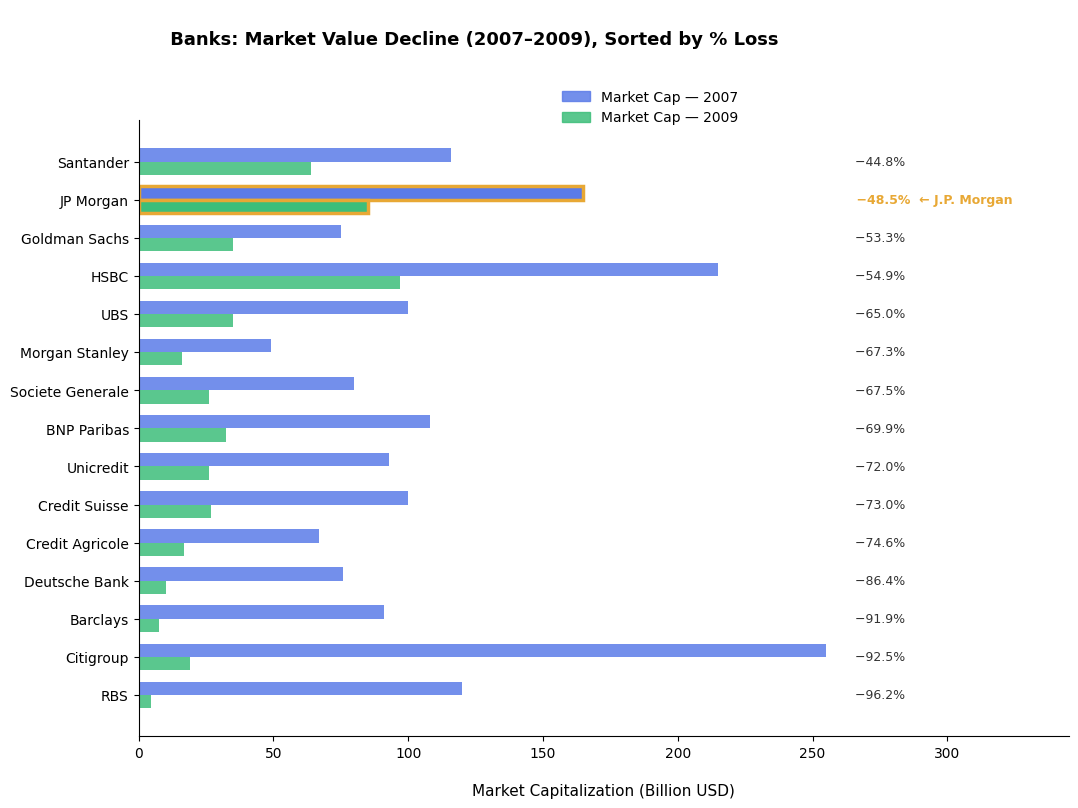

In [237]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(df))
bar_height = 0.35

color_2007 = '#5B7BE8'   # blue
color_2009 = '#3DBE7A'   # green
color_jp   = '#E8A835'   # highlight for JP Morgan

bars_2007 = ax.barh(y + bar_height/2, df['Value_2007'], bar_height,
                    color=color_2007, alpha=0.85, label='Market Cap Q2 2007')
bars_2009 = ax.barh(y - bar_height/2, df['Value_2009'], bar_height,
                    color=color_2009, alpha=0.85, label='Market Cap Jan 2009')

# Highlight JP Morgan bars
jp_idx = df[df['Bank'] == 'JP Morgan'].index[0]
ax.barh(jp_idx + bar_height/2, df.loc[jp_idx, 'Value_2007'], bar_height,
        color=color_2007, edgecolor=color_jp, linewidth=2.5)
ax.barh(jp_idx - bar_height/2, df.loc[jp_idx, 'Value_2009'], bar_height,
        color=color_2009, edgecolor=color_jp, linewidth=2.5)

# Annotate percentage loss on the right of each row
for i, row in df.iterrows():
    is_jp = row['Bank'] == 'JP Morgan'
    color = color_jp if is_jp else '#333333'
    weight = 'bold' if is_jp else 'normal'
    label = f"    −{row['Pct_Loss']:.1f}%"
    if is_jp:
        label += "  ← J.P. Morgan"
    ax.text(max(df['Value_2007']) + 5, i, label,
            va='center', ha='left', fontsize=9, color=color, fontweight=weight)
    

# Axis formatting
ax.set_yticks(y)
ax.set_yticklabels(df['Bank'], fontsize=10)
ax.set_xlabel('\nMarket Capitalization (Billion USD)', fontsize=11)
ax.set_title('\n     Banks: Market Value Decline (2007–2009), Sorted by % Loss\n',
             fontsize=13, fontweight='bold', pad=40, loc='left' )

ax.set_xlim(0, max(df['Value_2007']) + 90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
patch_2007 = mpatches.Patch(color=color_2007, alpha=0.85, label='Market Cap — 2007')
patch_2009 = mpatches.Patch(color=color_2009, alpha=0.85, label='Market Cap — 2009')
ax.legend(handles=[patch_2007, patch_2009], loc='upper center', bbox_to_anchor=(0.55, 1.07), fontsize=10, frameon=False )




plt.show()



**1. Shortcomings of the Original Graph**

The original visualization uses bubble charts (area-encoded circles) to represent market cap values for 2007 (blue) and 2009 (green), overlaid concentrically.

**Problems:**

- **Area perception is non-linear.** Humans are notoriously poor at comparing areas, especially when circles are overlaid. It's hard to judge how much smaller the green circle is than the blue one for any given bank.
- **Absolute losses are not directly shown.** The viewer must mentally subtract two bubble areas — a cognitively demanding task — rather than reading a loss value directly.
- **Percentage changes are completely invisible.** A bank that went from 20B to 10B (-50%) looks very different from one that went from 200B to 100B (-50%), even though the relative loss is identical. The visualization conflates absolute size with relative decline.
- **J.P. Morgan's story is poorly told.** The primary goal is to highlight J.P. Morgan's relative resilience, but the chart does not make this immediately obvious — it requires the viewer to notice that JP Morgan's green bubble is proportionally larger than peers.
- **Overlapping bubbles obscure one another.** Smaller 2009 values can be nearly hidden inside the 2007 bubbles, making comparison unreliable.
- **No direct labeling of loss.** The numbers shown are raw values; no annotation communicates how much was lost in absolute or relative terms.
- **Banks are not sorted meaningfully.** The x-axis order appears arbitrary, not ranked by loss or market cap, which hinders comparison.

---

**2. Proposed Improvements**

| Issue | Solution |
|------|--------|
| Area encoding hard to decode | Use length encoding (bar chart) — humans compare lengths far more accurately |
| Absolute losses not visible | Add an explicit "loss" bar or annotation per bank |
| Percentage change invisible | Add a secondary axis or percentage decline labels |
| J.P. Morgan not highlighted | Color-encode or annotate J.P. Morgan distinctly |
| No meaningful ordering | Sort banks by percentage decline (primary goal) |
| Overlapping bubbles | Separate the two values into grouped/stacked bars |

**Chosen design:** A grouped horizontal bar chart sorted by percentage decline, with:

- Two bars per bank (2007 in blue, 2009 in green) to show absolute values (secondary goal)
- Percentage decline annotated on each bank row
- J.P. Morgan highlighted with a distinct annotation
- Banks sorted from highest to lowest % loss (primary goal)

This directly answers both goals: absolute values are readable from bar lengths, and relative losses from the % labels and sort order.

---

**3. How the Redesign Achieves the Goals**

| Goal | How it's met |
|------|-------------|
| **Primary: Show extent of losses per bank** | Banks are sorted by % loss; the label column makes each bank's decline immediately readable |
| **Primary: Highlight J.P. Morgan's resilience** | J.P. Morgan appears near the bottom of the sorted list (least % lost) and is highlighted with a gold border + annotation |
| **Secondary: Show overall ranking by market size** | Bar lengths directly encode absolute values; larger banks (e.g., Citigroup, HSBC) are visually dominant |
| **Both absolute and relative losses** | Absolute via bar lengths; relative via % annotations |



---

## Section 4 - Geospatial Medal Visualization (30 points)


**Data Source:** `medals_total.csv`, `athletes.csv`.

Please create an interactive world map showing the Olympic performance of each country in Paris 2024. The visualization should include a dropdown menu with three possible metrics: **gold medals**, **total medals**, and **efficiency**. Selecting a different metric from the dropdown should update the map coloring so that countries are shaded according to the chosen value.

The efficiency metric should be defined as: **efficiency = total medals / number of athletes**

In addition, clicking on a country should display, **in a secondary output widget**, the distribution of athlete ages for that country.

Your final result should be runnable in a Jupyter notebook.

In [111]:
import os, json, requests
import numpy as np
import pandas as pd

from bokeh.application import Application
from bokeh.application.handlers import FunctionHandler
from bokeh.models import (
    GeoJSONDataSource, LinearColorMapper, ColorBar,
    Select, HoverTool, TapTool, ColumnDataSource, Div
)
from bokeh.palettes import YlOrRd9
from bokeh.plotting import figure
from bokeh.layouts import column, row
from bokeh.io import output_notebook, show

os.environ['BOKEH_ALLOW_WS_ORIGIN'] = '*'
output_notebook()

Loading BokehJS ...

In [113]:
# ── medals ────────────────────────────────────────────────────────────────────
medals = pd.read_csv('data-assignment1/medals_total.csv')
medals.columns = medals.columns.str.strip()

# ── athletes ──────────────────────────────────────────────────────────────────
athletes = pd.read_csv('data-assignment1/athletes.csv', low_memory=False)
athletes.columns = athletes.columns.str.strip()

# Keep only competing athletes
ath = athletes[athletes['function'].str.lower() == 'athlete'].copy()
ath['birth_date'] = pd.to_datetime(ath['birth_date'], errors='coerce')
ath['age'] = (pd.Timestamp('2024-07-26') - ath['birth_date']).dt.days / 365.25

# Athlete count per country
ath_count = ath.groupby('country_code').size().reset_index(name='n_athletes')

# ── merge ─────────────────────────────────────────────────────────────────────
df = medals.merge(ath_count, on='country_code', how='left')
df['n_athletes'] = df['n_athletes'].fillna(1)
df['efficiency']  = df['Total'] / df['n_athletes']

# Age data per IOC code — used in the tap callback
age_by_country = (
    ath.dropna(subset=['age'])
       .groupby('country_code')['age']
       .apply(list)
       .to_dict()
)

print(f"Countries with medals : {len(df)}")
print(f"Athletes with ages    : {ath['age'].notna().sum()}")
df.head(3)

Countries with medals : 92
Athletes with ages    : 10924


,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total,n_athletes,efficiency
0,USA,United States,United States of America,40,44,42,126,605,0.208264
1,CHN,China,People's Republic of China,40,27,24,91,394,0.230964
2,JPN,Japan,Japan,20,12,13,45,423,0.106383


In [114]:
# Natural Earth 110m — properties contain ISO_A3 and ISO_A3_EH
GEO_URL = (
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector"
    "/master/geojson/ne_110m_admin_0_countries.geojson"
)
geo = requests.get(GEO_URL).json()
print(f"GeoJSON features: {len(geo['features'])}")

# Preview the relevant properties on one feature
sample = geo['features'][0]['properties']
print(f"\nSample feature properties available:")
print({k: sample[k] for k in ['ADMIN','ISO_A3','ISO_A3_EH','ISO_A2','NAME'] if k in sample})

GeoJSON features: 177

Sample feature properties available:
{'ADMIN': 'Fiji', 'ISO_A3': 'FJI', 'ISO_A3_EH': 'FJI', 'ISO_A2': 'FJ', 'NAME': 'Fiji'}


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: extract the best available ISO-3 code from a Natural Earth feature.
# Priority: ISO_A3 (if not "-99") → ISO_A3_EH → ADM0_A3 → fallback string
# This handles the known France / Norway / Kosovo "-99" bug.
# ─────────────────────────────────────────────────────────────────────────────
def get_iso3(props):
    for field in ('ISO_A3', 'ISO_A3_EH', 'ADM0_A3', 'SOV_A3'):
        val = props.get(field, '-99')
        if val and val != '-99':
            return val
    return props.get('ADMIN', 'UNK')[:3].upper()   # last resort

# ─────────────────────────────────────────────────────────────────────────────
# Residual ISO-3 → IOC table  (only entries where the codes differ)
# Source: https://en.wikipedia.org/wiki/List_of_IOC_country_codes
# ─────────────────────────────────────────────────────────────────────────────
ISO3_TO_IOC = {
    # ISO-3 : IOC
    'DEU': 'GER',   # Germany
    'NLD': 'NED',   # Netherlands
    'CHE': 'SUI',   # Switzerland
    'DNK': 'DEN',   # Denmark
    'GRC': 'GRE',   # Greece
    'IRN': 'IRI',   # Iran
    'MYS': 'MAS',   # Malaysia
    'PHL': 'PHI',   # Philippines
    'IDN': 'INA',   # Indonesia
    'ZWE': 'ZIM',   # Zimbabwe
    'TTO': 'TTO',   # Trinidad & Tobago — same ✓ (listed for clarity)
    'VNM': 'VIE',   # Vietnam
    'MNG': 'MGL',   # Mongolia
    'KHM': 'CAM',   # Cambodia
    'MKD': 'MKD',   # North Macedonia — same ✓
    'BIH': 'BIH',   # Bosnia — same ✓
    'PRK': 'PRK',   # North Korea — same ✓
    'TWN': 'TPE',   # Chinese Taipei (Taiwan)
    'HKG': 'HKG',   # Hong Kong — same ✓
    'PRI': 'PUR',   # Puerto Rico
    'VIR': 'ISV',   # US Virgin Islands
    'GUF': 'FRA',   # French Guiana → maps to FRA delegation
    'REU': 'FRA',   # Réunion → maps to FRA delegation  
    'MTQ': 'FRA',   # Martinique → maps to FRA delegation
    'GLP': 'FRA',   # Guadeloupe → maps to FRA delegation
    'TZA': 'TAN',   # Tanzania
    'ZMB': 'ZAM',   # Zambia
    'MDG': 'MAD',   # Madagascar
    'MWI': 'MAW',   # Malawi
    'MUS': 'MRI',   # Mauritius
    'SYC': 'SEY',   # Seychelles
    'SLE': 'SLE',   # Sierra Leone — same ✓
    'BFA': 'BUR',   # Burkina Faso
    'NER': 'NIG',   # Niger
    'TCD': 'CHA',   # Chad
    'MRT': 'MTN',   # Mauritania
    'GMB': 'GAM',   # Gambia
    'GNB': 'GBS',   # Guinea-Bissau
    'LBR': 'LBR',   # Liberia — same ✓
    'SOM': 'SOM',   # Somalia — same ✓
    'SDN': 'SUD',   # Sudan
    'SSD': 'SSD',   # South Sudan — same ✓
    'COD': 'COD',   # DR Congo — same ✓
    'COG': 'CGO',   # Republic of Congo
    'CAF': 'CAF',   # Central African Republic — same ✓
    'GNQ': 'GEQ',   # Equatorial Guinea
    'STP': 'STP',   # São Tomé — same ✓
    'CPV': 'CPV',   # Cape Verde — same ✓
    'COM': 'COM',   # Comoros — same ✓
    'LBY': 'LBA',   # Libya
    'SAU': 'KSA',   # Saudi Arabia
    'ARE': 'UAE',   # United Arab Emirates
    'QAT': 'QAT',   # Qatar — same ✓
    'KWT': 'KUW',   # Kuwait
    'BHR': 'BRN',   # Bahrain
    'OMN': 'OMA',   # Oman
    'IRQ': 'IRQ',   # Iraq — same ✓
    'SYR': 'SYR',   # Syria — same ✓
    'JOR': 'JOR',   # Jordan — same ✓
    'LBN': 'LIB',   # Lebanon
    'PSE': 'PLE',   # Palestine
    'AFG': 'AFG',   # Afghanistan — same ✓
    'NPL': 'NEP',   # Nepal
    'MDV': 'MDV',   # Maldives — same ✓
    'BTN': 'BHU',   # Bhutan
    'MMR': 'MYA',   # Myanmar
    'BRN': 'BRU',   # Brunei
    'TLS': 'TLS',   # Timor-Leste — same ✓
    'PNG': 'PNG',   # Papua New Guinea — same ✓
    'FJI': 'FIJ',   # Fiji
    'WSM': 'SAM',   # Samoa
    'TON': 'TGA',   # Tonga
    'VUT': 'VAN',   # Vanuatu
    'SLB': 'SOL',   # Solomon Islands
}

def iso3_to_ioc(iso3):
    """Convert ISO 3166-1 alpha-3 to IOC code.
    If not in the residual table, the codes are identical → return as-is."""
    return ISO3_TO_IOC.get(iso3, iso3)

# ─────────────────────────────────────────────────────────────────────────────
# AUDIT
# ─────────────────────────────────────────────────────────────────────────────
medal_ioc_codes = set(df['country_code'])

# Build a lookup: IOC code → feature index in the GeoJSON
geo_ioc_map = {}
for i, feat in enumerate(geo['features']):
    iso3 = get_iso3(feat['properties'])
    ioc  = iso3_to_ioc(iso3)
    geo_ioc_map[ioc] = i

matched   = []
unmatched = []
for ioc in sorted(medal_ioc_codes):
    if ioc in geo_ioc_map:
        matched.append(ioc)
    else:
        unmatched.append(ioc)

print(f"{'='*50}")
print(f" Medal countries         : {len(medal_ioc_codes)}")
print(f" ✅ Matched in GeoJSON   : {len(matched)}")
print(f" ❌ NOT found in GeoJSON : {len(unmatched)}")
print(f"{'='*50}")

if unmatched:
    print("\n⚠️  Countries with medals NOT shown on the map:")
    miss = df[df['country_code'].isin(unmatched)][['country_code','country','Gold Medal','Total']]
    print(miss.to_string(index=False))
    print("\n(These are delegations without a sovereign polygon — e.g. Refugee Team, Kosovo)")
else:
    print("\n✅ Every medal-winning country is correctly mapped to a polygon!")

# Also show how many GeoJSON features got -99 fixed by the fallback
fixed = [(f['properties'].get('ADMIN'), f['properties'].get('ISO_A3'))
         for f in geo['features'] if f['properties'].get('ISO_A3') == '-99']
print(f"\nFeatures where ISO_A3='-99' (fixed via ISO_A3_EH fallback): {len(fixed)}")
for name, _ in fixed:
    print(f"  → {name}")

 Medal countries         : 92
 ✅ Matched in GeoJSON   : 74
 ❌ NOT found in GeoJSON : 18

⚠️  Countries with medals NOT shown on the map:
country_code          country  Gold Medal  Total
         BUL         Bulgaria           3      7
         CRO          Croatia           2      7
         BRN          Bahrain           2      4
         SLO         Slovenia           2      3
         HKG Hong Kong, China           2      4
         ALG          Algeria           2      3
         RSA     South Africa           1      6
         AIN              AIN           1      5
         POR         Portugal           1      4
         BOT         Botswana           1      2
         CHI            Chile           1      2
         LCA      Saint Lucia           1      2
         GUA        Guatemala           1      2
         DMA         Dominica           1      1
         GRN          Grenada           0      2
         CPV       Cabo Verde           0      1
         EOR              EOR 

In [116]:
medal_lookup = df.set_index('country_code')[['Gold Medal','Total','efficiency']].to_dict('index')

def build_geo_source(metric_col):
    """
    Pipeline for each GeoJSON feature:
      ISO_A3 / ISO_A3_EH  →  get_iso3()  →  iso3_to_ioc()  →  medal_lookup
    
    Countries with no medal data get metric_value=None
    → LinearColorMapper renders them with nan_color (light gray).
    """
    features = []
    for feat in geo['features']:
        props    = feat['properties']
        iso3     = get_iso3(props)
        ioc      = iso3_to_ioc(iso3)
        row_data = medal_lookup.get(ioc, {})
        val      = row_data.get(metric_col, None)

        f = dict(feat)
        f['properties'] = dict(props)
        f['properties']['metric_value'] = val
        f['properties']['ioc_code']     = ioc
        f['properties']['name']         = props.get('ADMIN', props.get('NAME', ioc))
        f['properties']['gold']         = row_data.get('Gold Medal', 'N/A')
        f['properties']['total']        = row_data.get('Total', 'N/A')
        eff = row_data.get('efficiency')
        f['properties']['efficiency']   = round(eff, 4) if eff is not None else 'N/A'
        features.append(f)

    geo_copy = dict(geo)
    geo_copy['features'] = features
    return GeoJSONDataSource(geojson=json.dumps(geo_copy))

PALETTE    = list(reversed(YlOrRd9))
METRIC_MAP = {
    'Gold Medals':  'Gold Medal',
    'Total Medals': 'Total',
    'Efficiency':   'efficiency',
}
MAX_VAL = {col: df[col].max() for col in METRIC_MAP.values()}

print("Helper ready.")

Helper ready.


In [117]:
def modify_doc(doc):

    geo_src = build_geo_source('Gold Medal')

    color_mapper = LinearColorMapper(
        palette=PALETTE,
        low=0,
        high=MAX_VAL['Gold Medal'],
        nan_color='#d3d3d3',
    )

    p = figure(
        title='Paris 2024 Olympics — Gold Medals by Country',
        width=850, height=460,
        toolbar_location='right',
        x_range=(-200, 200),
        y_range=(-90, 90),
    )
    p.axis.visible = False
    p.grid.grid_line_color = None
    p.background_fill_color = '#eaf2fb'
    p.title.text_font_size  = '13pt'

    patches = p.patches(
        xs='xs', ys='ys',
        source=geo_src,
        fill_color={'field': 'metric_value', 'transform': color_mapper},
        line_color='white',
        line_width=0.4,
        fill_alpha=0.85,
        hover_fill_alpha=1.0,
        hover_line_color='black',
        hover_line_width=1.5,
        nonselection_fill_alpha=0.55,
    )

    p.add_tools(
        HoverTool(renderers=[patches], tooltips=[
            ('Country',    '@name'),
            ('IOC Code',   '@ioc_code'),
            ('Gold',       '@gold'),
            ('Total',      '@total'),
            ('Efficiency', '@efficiency'),
        ]),
        TapTool(renderers=[patches]),
    )

    color_bar = ColorBar(color_mapper=color_mapper, location=(0, 0), width=10)
    p.add_layout(color_bar, 'right')

    hist_src = ColumnDataSource(dict(top=[], left=[], right=[]))
    hist_fig = figure(
        title='Click a country on the map',
        width=380, height=260,
        toolbar_location=None,
        x_axis_label='Age (years)',
        y_axis_label='# Athletes',
    )
    hist_fig.quad(
        top='top', bottom=0, left='left', right='right',
        source=hist_src,
        fill_color='#e85d04', line_color='white', fill_alpha=0.85,
    )
    hist_fig.background_fill_color = '#eaf2fb'

    info_div = Div(text='', width=380,
                   styles={'font-size': '12px', 'color': '#333', 'padding-top': '4px'})

    select = Select(
        title='Metric:',
        value='Gold Medals',
        options=list(METRIC_MAP.keys()),
        width=200,
    )

    def update_data(attr, old, new):
        col               = METRIC_MAP[select.value]
        new_src           = build_geo_source(col)
        geo_src.geojson   = new_src.geojson
        color_mapper.high = MAX_VAL[col]
        p.title.text      = f'Paris 2024 Olympics — {select.value} by Country'

    def update_hist(attr, old, new):
        if not new:
            return
        idx   = new[0]
        gjson = json.loads(geo_src.geojson)
        feat  = gjson['features'][idx]
        ioc   = feat['properties'].get('ioc_code', '')
        cname = feat['properties'].get('name', ioc)

        ages = age_by_country.get(ioc, [])
        if ages:
            counts, edges = np.histogram(ages, bins=15)
            hist_src.data = dict(top=counts, left=edges[:-1], right=edges[1:])
            hist_fig.title.text = f'Athlete Ages — {cname}'
            n   = len(ages)
            avg = round(float(np.mean(ages)), 1)
            mn  = round(float(np.min(ages)),  1)
            mx  = round(float(np.max(ages)),  1)
            info_div.text = (
                f'<b>{cname}</b> &nbsp;·&nbsp; <b>{n}</b> athletes &nbsp;·&nbsp; '
                f'avg age <b>{avg}</b> &nbsp;·&nbsp; range <b>{mn}–{mx}</b> yrs'
            )
        else:
            hist_src.data       = dict(top=[], left=[], right=[])
            hist_fig.title.text = f'{cname} — no age data'
            info_div.text       = f'<b>{cname}</b>: no athlete age data available.'

    select.on_change('value', update_data)
    geo_src.selected.on_change('indices', update_hist)

    doc.add_root(
        row(
            column(select),
            column(p, row(column(hist_fig, info_div)))
        )
    )


handler = FunctionHandler(modify_doc)
app     = Application(handler)
show(app)

ERROR:tornado.application:Uncaught exception GET /ws?id=6e7cc5a0-57de-46ed-ae7a-cdd42d4767d7&parentId=8&origin=f9a8f137-6329-409b-b15d-84cdddeafb0d&swVersion=4&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer (::1)
HTTPServerRequest(protocol='http', host='localhost:53213', method='GET', uri='/ws?id=6e7cc5a0-57de-46ed-ae7a-cdd42d4767d7&parentId=8&origin=f9a8f137-6329-409b-b15d-84cdddeafb0d&swVersion=4&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/Users/michele/Desktop/Visual Analytics/assignment 1/python-data-visualization/.venv/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwar

---

## Datasets description

You can find the data in the folder [data-assignment1](https://drive.google.com/file/d/1e6FVt8i5WMFg8HLxmvhCExs_hv3lT5tx/view?usp=share_link). The descriptions of the datasets are provided below.

### Yellow NYC

Data file `yellow_nyc.csv`:

| Column                    | Description |
|------------------------------|---------------|
| `pickup_time`               | Date and time when the ride began (`datetime`). |
| `dropoff_time`              | Date and time when the ride ended (`datetime`). |
| `passenger_count`              | Number of passengers in the vehicle. |
| `pickup_longitude`              | Longitude of the pickup location (type `float64`). |
| `pickup_latitude`              | Latitude of the pickup location (type `float64`). |
| `dropoff_longitude`              | Longitude of the dropoff location (type `float64`). |
| `dropoff_latitude`              | Latitude of the dropoff location (type `float64`). |
| `trip_distance`              | Distance covered during the ride in miles. |
| `payment_type`              | Method used to pay for the ride (e.g., credit card, cash). If the ride is a `Voucher ride`, the passenger is not charged for the ride, as the fare is already covered by a pre-purchased voucher. |
| `fare_amount`              | Base fare charged for the ride, excluding surcharges and tolls. |
| `mta_tax`              | \$0.50 MTA tax. Automatically triggered for rides shorter than 5 miles, \$0 otherwise. |
| `overnight_tax`              | Additional surcharge: \$1.00 for rides starting between midnight and 6am, \$0 otherwise. |
| `improvement_surcharge`              | Additional \$0.30 surcharge applied to every ride. Introduced on January 1st, 2016. |
| `tolls_amount`              | Total toll charges incurred during the ride. |
| `total_amount`              | Total amount charged to the passenger, including fare, all surcharges, and tolls. |

#### Payment Type Encoding
| **Code**                    | **Payment Method** |
|------------------------------|---------------|
| 1               | Credit card |
| 2               | Cash |
| 3               | Voucher ride |
| 4               | Dispute |
| 5               | Unknown |

### Air pollution

Data file `air_pollution.csv`:

| Column                    | Description |
|------------------------------|---------------|
| `stationid`                 | Unique identifier of the station. |
| `datetime`                  | Date and time when the measure was recorded (`datetime`). |
| `pm2.5`                     | Measured concentration of Particulate Matter 2.5-micrometer. Unit of measure: $\mu g / m^3$|
| `pm10`                      | Measured concentration of Particulate Matter 10-micrometer. Unit of measure: $\mu g / m^3$ |
| `no`                        | Measured concentration of Nitric Oxide. Unit of measure: $ppb$ |
| `no2`                       | Measured concentration of Nitric Dioxide. Unit of measure: $ppb$ |
| `nox`                       | Measured concentration of any Nitric x-oxide. Unit of measure: $ppb$ |
| `nh3`                       | Measured concentration of Ammonia. Unit of measure: $ppb$ |
| `co`                        | Measured concentration of Carbon Monoxide. Unit of measure: $ppb$ |
| `so2`                       | Measured concentration of Sulphur Dioxide. Unit of measure: $ppb$ |
| `aqi`                       | Air Quality Index. A standardized index used to report air quality levels. |
| `aqi_bucket`                       | A categorical subdivision between different ranges of AQI. |

### Stations dataset

Data file `stations.csv`:
| Column                    | Description |
|------------------------------|---------------|
| `StationId`                 | Unique identifier of the station. |
| `StationName`               | Name of the station. |
| `City`                      | City where the station is. |
| `State`                     | State where the station is. |
| `Status`                    | Station activity status. |


### Paris 2024 olympic summer games

Data file `medals_total.csv`:

| Column | Description |
|---|---|
| `country_code` | IOC 3-letter country code (e.g. `USA`, `GBR`, `GER`) |
| `country` | Country name |
| `country_long` | Full country name |
| `Gold Medal` | Number of gold medals won |
| `Silver Medal` | Number of silver medals won |
| `Bronze Medal` | Number of bronze medals won |
| `Total` | Sum of all medals (gold + silver + bronze) |

Data file `athletes.csv`:

| Column | Description |
|---|---|
| `code` | Unique numeric identifier for the person |
| `current` | Boolean — whether the record is current/active |
| `name` | Full official name |
| `name_short` | Shortened display name (usually "Firstname LASTNAME") |
| `name_tv` | Name formatted for TV broadcast graphics |
| `gender` | `Male` or `Female` |
| `function` | Role at the Games — `Athlete`, `Coach`, `Technical Official`, etc. |
| `country_code` | IOC 3-letter code of the competing country (e.g. `USA`, `GER`) |
| `country` | Short country name |
| `country_long` | Full official country name |
| `nationality` | Short nationality label |
| `nationality_long` | Full nationality label |
| `nationality_code` | IOC code for nationality (may differ from `country_code` for naturalised athletes) |
| `height` | Height in metres |
| `weight` | Weight in kilograms |
| `disciplines` | Sport discipline(s) the athlete is entered in |
| `events` | Specific event(s) within those disciplines |
| `birth_date` | Date of birth (YYYY-MM-DD) |
| `birth_place` | City/town of birth |
| `birth_country` | Country of birth |
| `residence_place` | City/town of current residence |
| `residence_country` | Country of current residence |
| `nickname` | Athlete's popular nickname or alias |
| `hobbies` | Self-reported hobbies and interests |
| `occupation` | Job or occupation outside of sport |
| `education` | Educational background |
| `family` | Free-text description of family situation |
| `lang` | Languages spoken |
| `coach` | Name(s) of the athlete's coach(es) |
| `reason` | Why the athlete started their sport |
| `hero` | Person(s) the athlete identifies as a hero or role model |
| `influence` | Greatest influence on their career |
| `philosophy` | Personal or sporting philosophy/motto |
| `sporting_relatives` | Family members who also compete in sport |
| `ritual` | Pre-competition rituals or superstitions |
| `other_sports` | Other sports the athlete practises |